# F1 Complete Exploratory Data Analysis
**Files covered:**
- Clean Circuits Data · Clean Drivers Data · Cleaned Pit Stops · Cleaned Qualifying Data
- Cleaned Races · Cleaned Results · Cleaned Seasons · Cleaned Status
- Constructor Results Clean · Constructor Standings · Constructors Clean Data
- Driver Standings · Lap Times Clean

**Structure:** One section per dataset → shape, dtypes, missing values, distributions, key relationships  
**Output:** Inline charts + `reports/eda_findings.md`

---
## 0. Setup & Load All Files

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── Directories ────────────────────────────────────────────────────────────────
DATA_DIR   = Path('.')          # adjust if CSVs are in a sub-folder
REPORT_DIR = Path('reports')
FIG_DIR    = Path('reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Global plot style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.figsize': (13, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})
sns.set_palette('tab10')
COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']

print('Setup complete.')

Setup complete.


In [2]:
# ── Load all 13 datasets ───────────────────────────────────────────────────────
circuits      = pd.read_csv(DATA_DIR / 'Clean Circuits Data.csv')
drivers       = pd.read_csv(DATA_DIR / 'Clean Drivers Data.csv')
pit_stops     = pd.read_csv(DATA_DIR / 'Cleaned Pit Stops.csv')
qualifying    = pd.read_csv(DATA_DIR / 'Cleaned Qualifying Data.csv')
races         = pd.read_csv(DATA_DIR / 'Cleaned Races.csv')
results       = pd.read_csv(DATA_DIR / 'Cleaned Results.csv')
seasons       = pd.read_csv(DATA_DIR / 'Cleaned Seasons.csv')
status        = pd.read_csv(DATA_DIR / 'Cleaned Status.csv')
con_results   = pd.read_csv(DATA_DIR / 'Constructor Results Clean.csv')
con_standings = pd.read_csv(DATA_DIR / 'Constructor Standings.csv')
constructors  = pd.read_csv(DATA_DIR / 'Constructors Clean Data.csv')
drv_standings = pd.read_csv(DATA_DIR / 'Driver Standings.csv')
lap_times     = pd.read_csv(DATA_DIR / 'Lap Times Clean.csv')

ALL_DFS = {
    'circuits': circuits,
    'drivers': drivers,
    'pit_stops': pit_stops,
    'qualifying': qualifying,
    'races': races,
    'results': results,
    'seasons': seasons,
    'status': status,
    'constructor_results': con_results,
    'constructor_standings': con_standings,
    'constructors': constructors,
    'driver_standings': drv_standings,
    'lap_times': lap_times,
}

for name, df in ALL_DFS.items():
    print(f'{name:25s}  rows={df.shape[0]:>8,}  cols={df.shape[1]:>3}')

circuits                   rows=      73  cols=  7
drivers                    rows=     841  cols= 10
pit_stops                  rows=   6,251  cols=  7
qualifying                 rows=   7,516  cols=  9
races                      rows=     997  cols=  8
results                    rows=  23,777  cols= 18
seasons                    rows=      69  cols=  2
status                     rows=     134  cols=  2
constructor_results        rows=  11,142  cols=  4
constructor_standings      rows=  11,896  cols=  8
constructors               rows=     208  cols=  4
driver_standings           rows=  31,726  cols=  8
lap_times                  rows= 426,633  cols=  7


---
## 1. Global Overview — Missing Values & Schema

In [3]:
# ── Summary table: shape + % missing per dataset ──────────────────────────────
summary_rows = []
for name, df in ALL_DFS.items():
    pct_missing = (df.isnull().sum().sum() / df.size * 100)
    summary_rows.append({
        'Dataset': name,
        'Rows': df.shape[0],
        'Columns': df.shape[1],
        '% Missing': round(pct_missing, 2)
    })

overview = pd.DataFrame(summary_rows)
print(overview.to_string(index=False))

              Dataset   Rows  Columns  % Missing
             circuits     73        7       0.00
              drivers    841       10       0.00
            pit_stops   6251        7       0.30
           qualifying   7516        9      13.78
                races    997        8       0.00
              results  23777       18       0.00
              seasons     69        2       0.00
               status    134        2       0.00
  constructor_results  11142        4       0.00
constructor_standings  11896        8       0.00
         constructors    208        4       0.00
     driver_standings  31726        8       0.00
            lap_times 426633        7       0.00


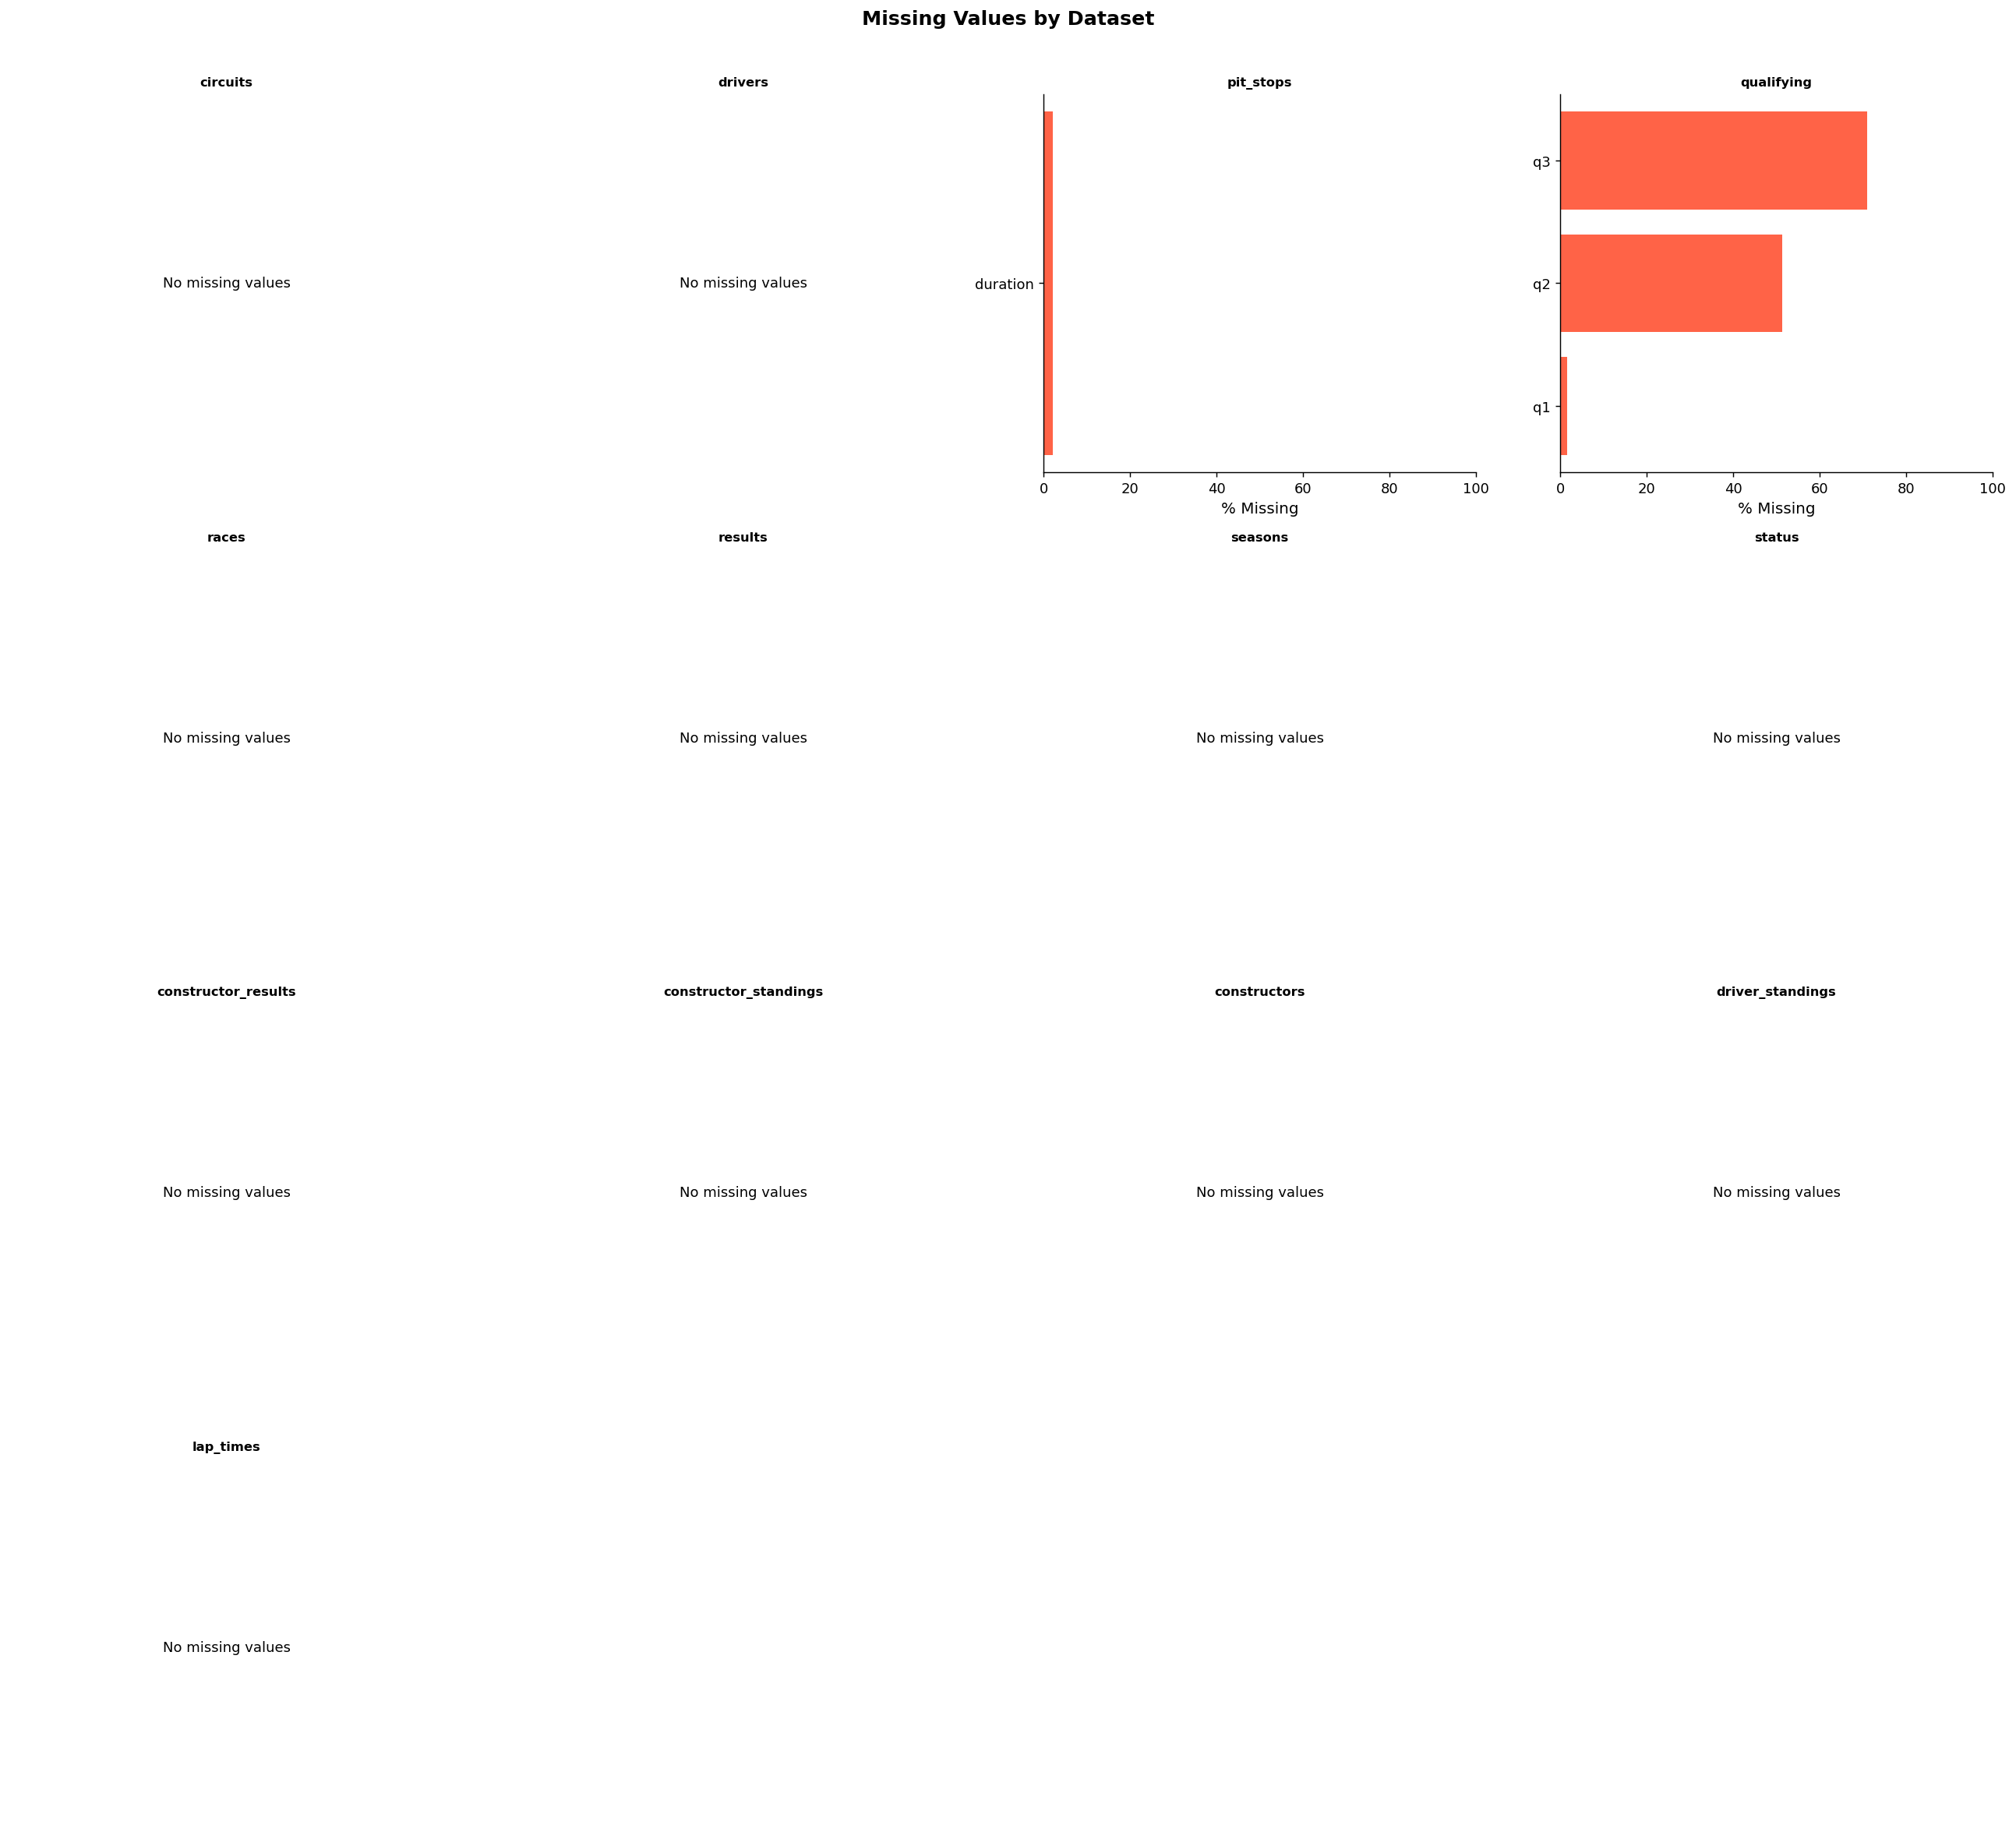

In [4]:
# ── Missing value heatmap ─────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 4, figsize=(20, 18))
axes = axes.flatten()

for i, (name, df) in enumerate(ALL_DFS.items()):
    missing = df.isnull().mean() * 100
    missing = missing[missing > 0]
    ax = axes[i]
    if len(missing) == 0:
        ax.text(0.5, 0.5, 'No missing values', ha='center', va='center', fontsize=10)
        ax.axis('off')
    else:
        ax.barh(missing.index, missing.values, color='tomato')
        ax.set_xlabel('% Missing')
        ax.set_xlim(0, 100)
    ax.set_title(name, fontsize=9, fontweight='bold')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Missing Values by Dataset', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '1_missing_values.png', bbox_inches='tight')
plt.show()

---
## 2. Circuits

In [5]:
print('=== Circuits — Info ===')
print(circuits.dtypes)
print()
print(circuits.describe(include='all').T)

=== Circuits — Info ===
circuitId       int64
circuitRef     object
name           object
location       object
country        object
lat           float64
lng           float64
dtype: object

           count unique                             top freq       mean  \
circuitId   73.0    NaN                             NaN  NaN       37.0   
circuitRef    73     73                     albert_park    1        NaN   
name          73     73  Albert Park Grand Prix Circuit    1        NaN   
location      73     70                      California    2        NaN   
country       73     32                             Usa   11        NaN   
lat         73.0    NaN                             NaN  NaN  33.872365   
lng         73.0    NaN                             NaN  NaN   1.722826   

                  std      min      25%      50%      75%      max  
circuitId   21.217131      1.0     19.0     37.0     55.0     73.0  
circuitRef        NaN      NaN      NaN      NaN      NaN      NaN  

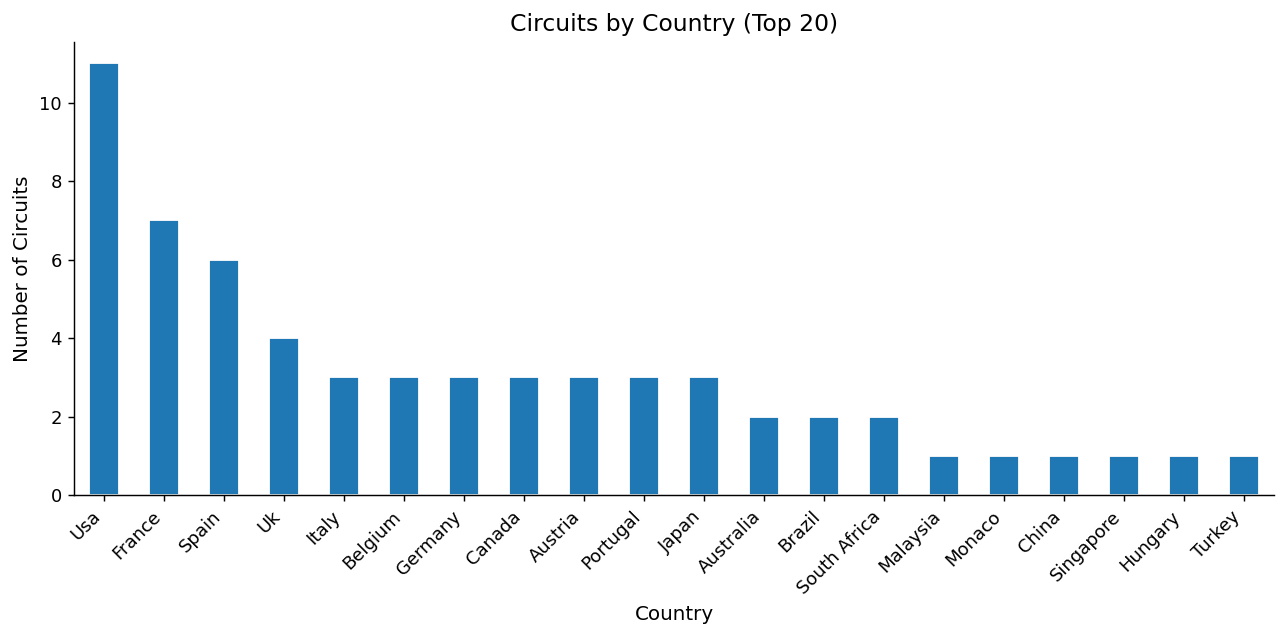

In [6]:
# ── Circuits by country ───────────────────────────────────────────────────────
country_col = [c for c in circuits.columns if 'country' in c.lower()]
if country_col:
    ctry = circuits[country_col[0]].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(10, 5))
    ctry.plot(kind='bar', ax=ax, color=COLORS[0], edgecolor='white')
    ax.set_title('Circuits by Country (Top 20)')
    ax.set_xlabel('Country')
    ax.set_ylabel('Number of Circuits')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '2_circuits_by_country.png', bbox_inches='tight')
    plt.show()

In [7]:
# ── Circuit altitude distribution ─────────────────────────────────────────────
alt_col = [c for c in circuits.columns if 'alt' in c.lower()]
if alt_col:
    alt_data = pd.to_numeric(circuits[alt_col[0]], errors='coerce').dropna()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(alt_data, bins=20, color=COLORS[1], edgecolor='white')
    axes[0].set_title('Altitude Distribution of Circuits')
    axes[0].set_xlabel('Altitude (m)')
    axes[0].set_ylabel('Count')

    # Scatter lat vs lng coloured by altitude
    lat_col = [c for c in circuits.columns if 'lat' in c.lower()]
    lng_col = [c for c in circuits.columns if 'lng' in c.lower() or 'lon' in c.lower()]
    if lat_col and lng_col:
        sc = axes[1].scatter(
            pd.to_numeric(circuits[lng_col[0]], errors='coerce'),
            pd.to_numeric(circuits[lat_col[0]], errors='coerce'),
            c=alt_data.reindex(circuits.index), cmap='YlOrRd', s=60, edgecolors='k', linewidths=0.4
        )
        plt.colorbar(sc, ax=axes[1], label='Altitude (m)')
        axes[1].set_title('Circuit Locations (coloured by Altitude)')
        axes[1].set_xlabel('Longitude')
        axes[1].set_ylabel('Latitude')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '2_circuit_altitude.png', bbox_inches='tight')
    plt.show()

---
## 3. Drivers

In [8]:
print('=== Drivers — Info ===')
print(drivers.dtypes)
print()
print(f'Total unique drivers: {len(drivers):,}')
print(drivers.head())

=== Drivers — Info ===
driverId         int64
driverRef       object
number           int64
code            object
forename        object
surname         object
dob             object
nationality     object
full_name       object
birth_year     float64
dtype: object

Total unique drivers: 841
   driverId   driverRef  number code  forename     surname         dob  \
0         1    hamilton      44  HAM     Lewis    Hamilton  1985-01-07   
1         2    heidfeld       0  HEI      Nick    Heidfeld  1977-05-10   
2         3     rosberg       6  ROS      Nico     Rosberg  1985-06-27   
3         4      alonso      14  ALO  Fernando      Alonso  1981-07-29   
4         5  kovalainen       0  KOV    Heikki  Kovalainen  1981-10-19   

  nationality          full_name  birth_year  
0     British     Lewis Hamilton      1985.0  
1      German      Nick Heidfeld      1977.0  
2      German       Nico Rosberg      1985.0  
3     Spanish    Fernando Alonso      1981.0  
4     Finnish  Heikki Kova

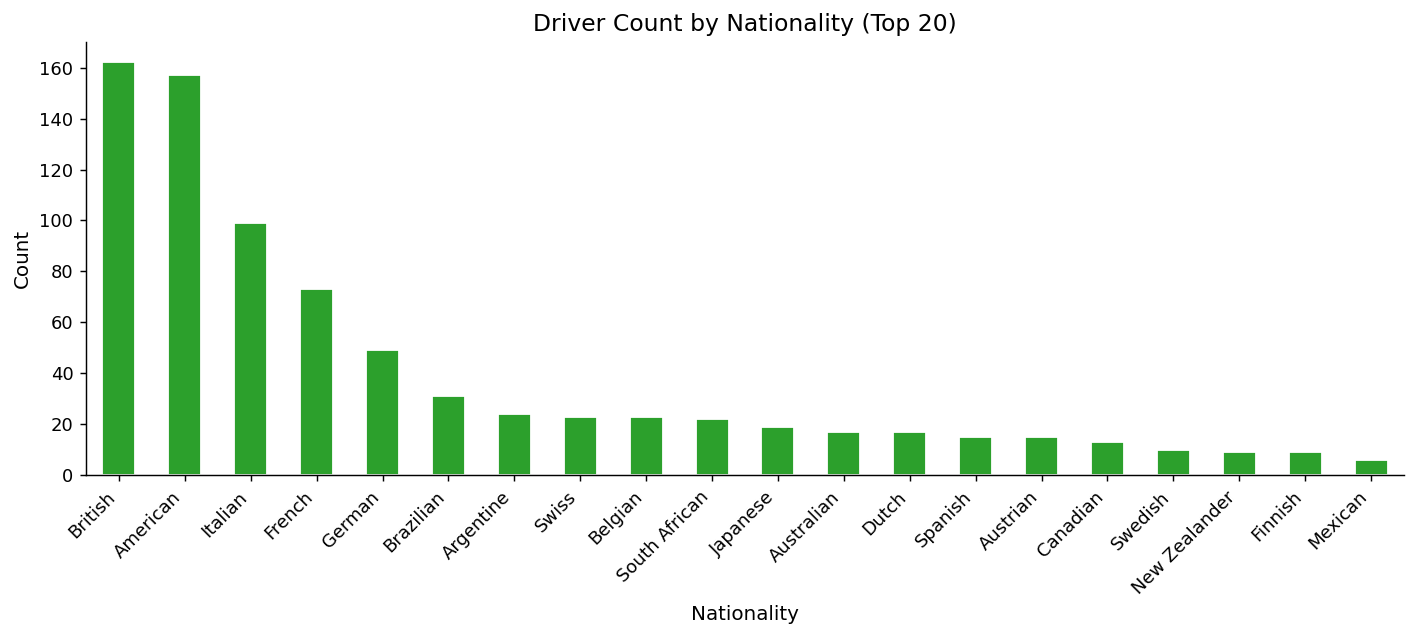

In [9]:
# ── Nationality distribution ───────────────────────────────────────────────────
nat_col = [c for c in drivers.columns if 'nation' in c.lower()]
if nat_col:
    nat = drivers[nat_col[0]].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(11, 5))
    nat.plot(kind='bar', ax=ax, color=COLORS[2], edgecolor='white')
    ax.set_title('Driver Count by Nationality (Top 20)')
    ax.set_xlabel('Nationality')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '3_driver_nationality.png', bbox_inches='tight')
    plt.show()

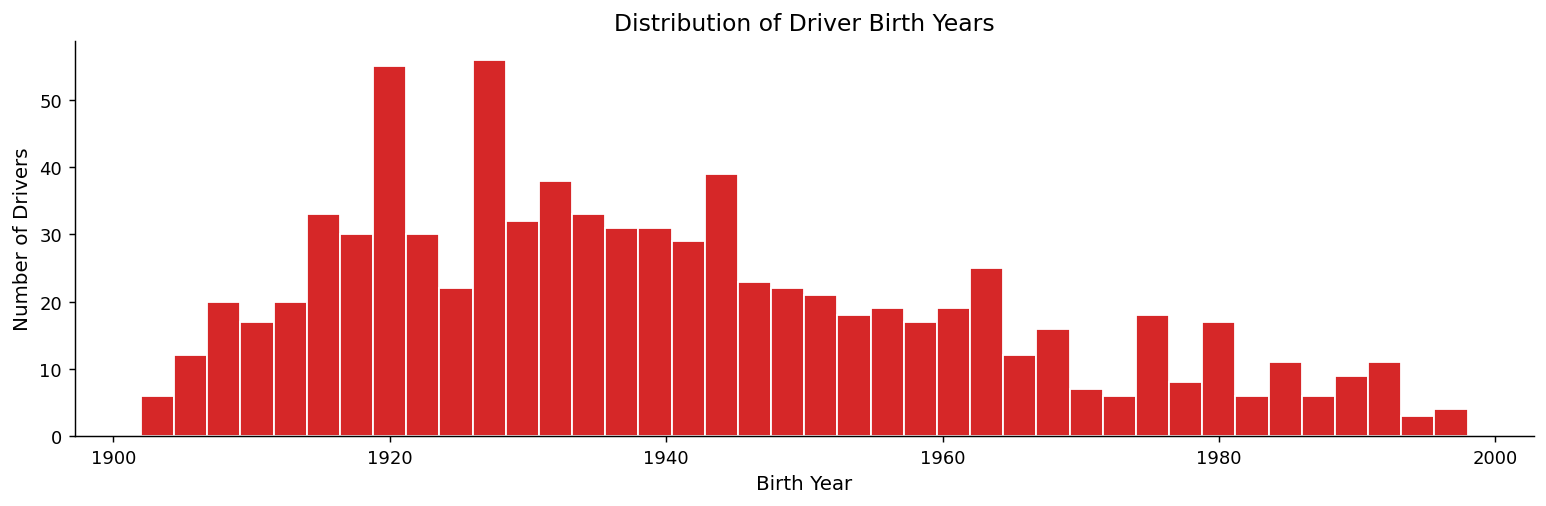

Earliest birth year: 1902  |  Latest: 1998


In [10]:
# ── Driver age (from DOB) distribution ────────────────────────────────────────
dob_col = [c for c in drivers.columns if 'dob' in c.lower() or 'birth' in c.lower() or 'date' in c.lower()]
if dob_col:
    dob = pd.to_datetime(drivers[dob_col[0]], errors='coerce')
    drivers['birth_year'] = dob.dt.year
    valid_years = drivers['birth_year'].dropna()
    valid_years = valid_years[(valid_years > 1900) & (valid_years < 2010)]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.hist(valid_years, bins=40, color=COLORS[3], edgecolor='white')
    ax.set_title('Distribution of Driver Birth Years')
    ax.set_xlabel('Birth Year')
    ax.set_ylabel('Number of Drivers')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '3_driver_birth_year.png', bbox_inches='tight')
    plt.show()
    print(f'Earliest birth year: {int(valid_years.min())}  |  Latest: {int(valid_years.max())}')

---
## 4. Seasons

In [11]:
print('=== Seasons — Info ===')
print(seasons.dtypes)
print()
print(seasons.describe(include='all').T)
print()
print(seasons.head(10))

=== Seasons — Info ===
year     int64
url     object
dtype: object

     count unique                                                top freq  \
year  69.0    NaN                                                NaN  NaN   
url     69     69  http://en.wikipedia.org/wiki/2009_Formula_One_...    1   

        mean        std     min     25%     50%     75%     max  
year  1984.0  20.062403  1950.0  1967.0  1984.0  2001.0  2018.0  
url      NaN        NaN     NaN     NaN     NaN     NaN     NaN  

   year                                                url
0  2009  http://en.wikipedia.org/wiki/2009_Formula_One_...
1  2008  http://en.wikipedia.org/wiki/2008_Formula_One_...
2  2007  http://en.wikipedia.org/wiki/2007_Formula_One_...
3  2006  http://en.wikipedia.org/wiki/2006_Formula_One_...
4  2005  http://en.wikipedia.org/wiki/2005_Formula_One_...
5  2004  http://en.wikipedia.org/wiki/2004_Formula_One_...
6  2003  http://en.wikipedia.org/wiki/2003_Formula_One_...
7  2002  http://en.wikipedia.

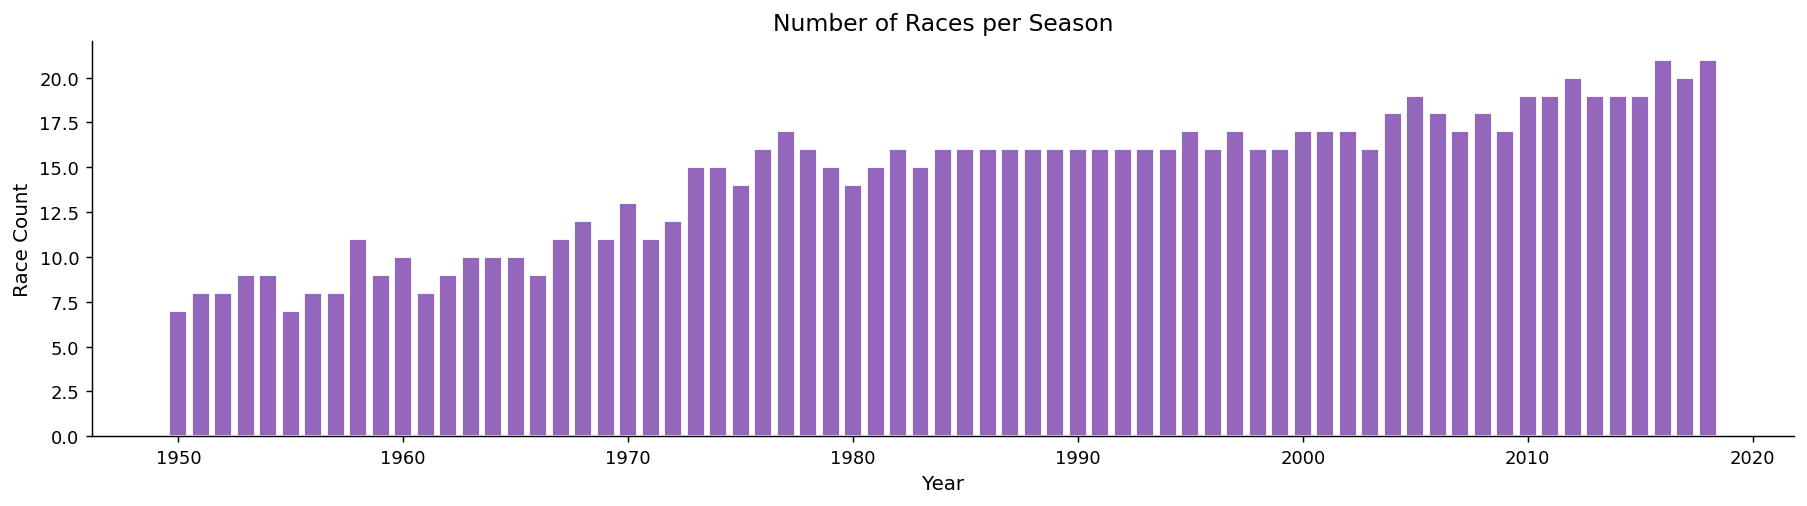

Season range: 1950 – 2018
Max races in a season: 21 (2016)


In [12]:
# ── Races per season ─────────────────────────────────────────────────────────
year_col = [c for c in races.columns if 'year' in c.lower()]
if year_col:
    races_per_year = races[year_col[0]].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(races_per_year.index, races_per_year.values, color=COLORS[4], edgecolor='white', width=0.8)
    ax.set_title('Number of Races per Season')
    ax.set_xlabel('Year')
    ax.set_ylabel('Race Count')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '4_races_per_season.png', bbox_inches='tight')
    plt.show()
    print(f'Season range: {int(races_per_year.index.min())} – {int(races_per_year.index.max())}')
    print(f'Max races in a season: {races_per_year.max()} ({int(races_per_year.idxmax())})')

---
## 5. Races

In [13]:
print('=== Races — Info ===')
print(races.dtypes)
print()
print(races.describe(include='all').T)

=== Races — Info ===
raceId        int64
year          int64
round         int64
circuitId     int64
name         object
date         object
time         object
url          object
dtype: object

           count unique                                                top  \
raceId     997.0    NaN                                                NaN   
year       997.0    NaN                                                NaN   
round      997.0    NaN                                                NaN   
circuitId  997.0    NaN                                                NaN   
name         997     42                                 British Grand Prix   
date         997    997                                         2018-11-25   
time         997     21                                            Unknown   
url          997    997  http://en.wikipedia.org/wiki/2018_Abu_Dhabi_Gr...   

          freq         mean         std     min     25%     50%     75%  \
raceId     NaN   500.03410

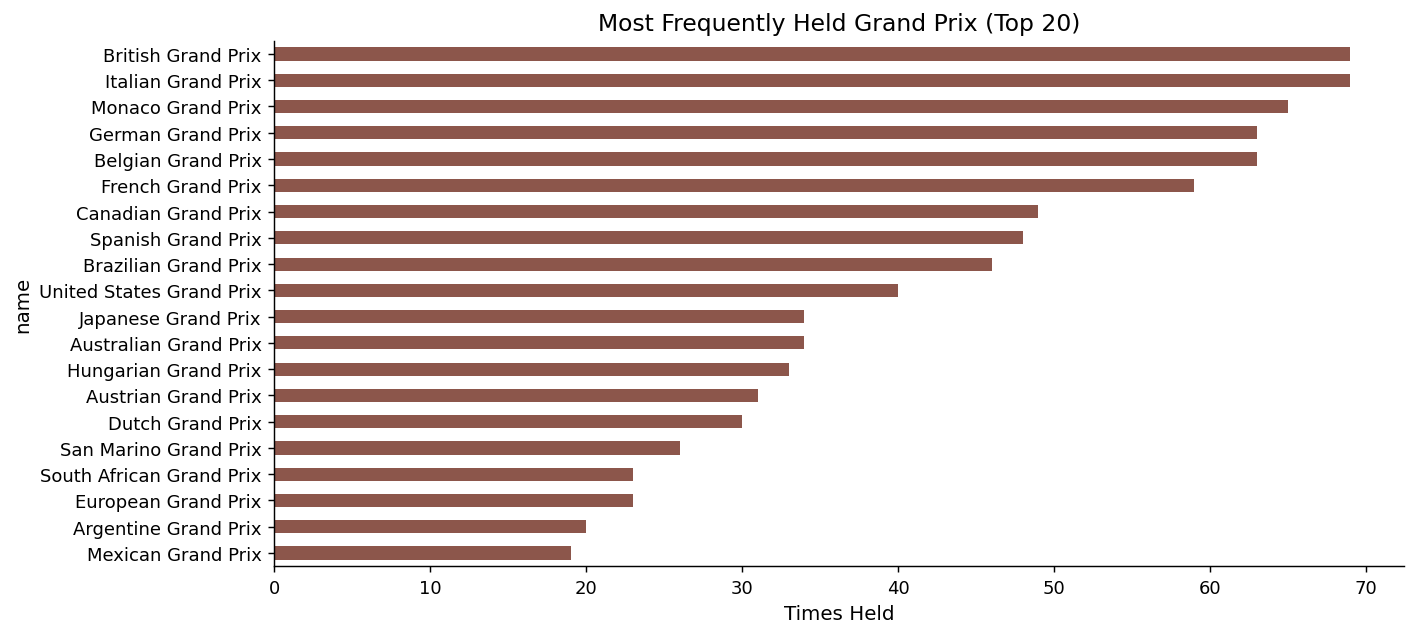

In [14]:
# ── Most frequently held Grand Prix ──────────────────────────────────────────
name_col = [c for c in races.columns if 'name' in c.lower()]
if name_col:
    gp_counts = races[name_col[0]].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(11, 5))
    gp_counts.plot(kind='barh', ax=ax, color=COLORS[5])
    ax.set_title('Most Frequently Held Grand Prix (Top 20)')
    ax.set_xlabel('Times Held')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '5_frequent_gp.png', bbox_inches='tight')
    plt.show()

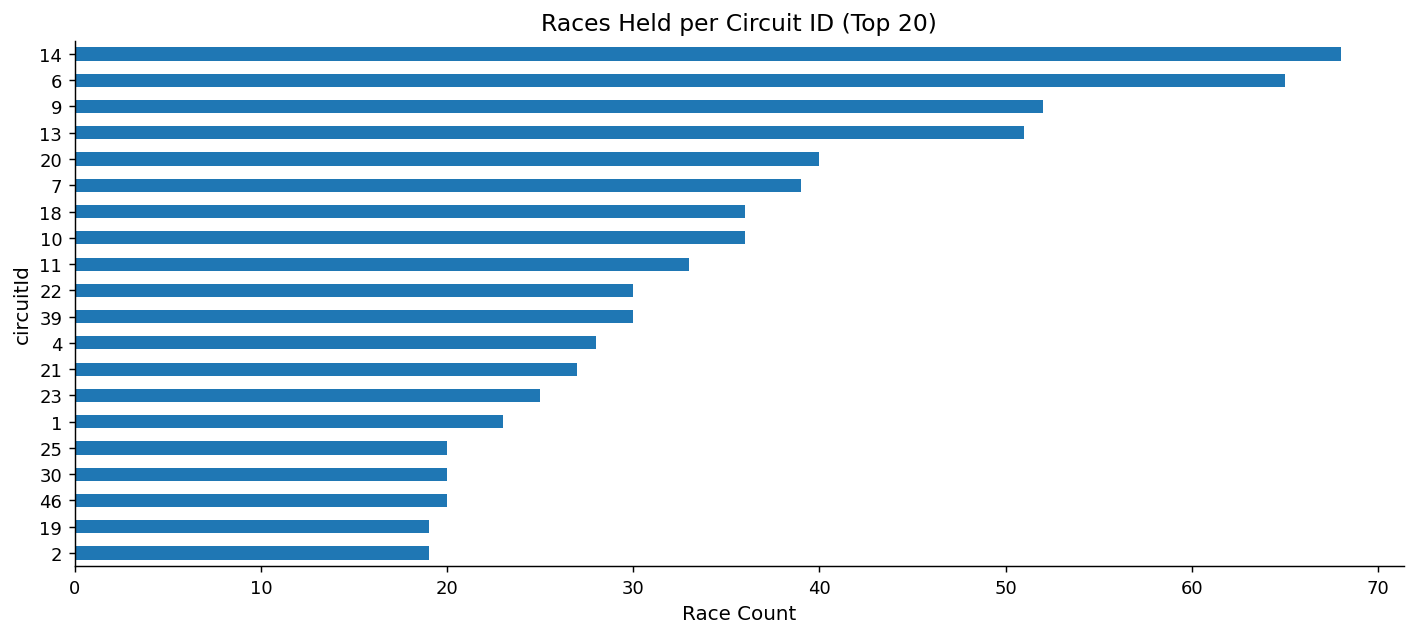

In [15]:
# ── Races per circuit ─────────────────────────────────────────────────────────
circuit_col = [c for c in races.columns if 'circuit' in c.lower()]
if circuit_col:
    top_circuits = races[circuit_col[0]].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(11, 5))
    top_circuits.plot(kind='barh', ax=ax, color=COLORS[0])
    ax.set_title('Races Held per Circuit ID (Top 20)')
    ax.set_xlabel('Race Count')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '5_races_per_circuit.png', bbox_inches='tight')
    plt.show()

---
## 6. Status

In [16]:
print('=== Status — Info ===')
print(status.dtypes)
print()
print(status.head(10))

=== Status — Info ===
statusId     int64
status      object
dtype: object

   statusId        status
0         1      Finished
1         2  Disqualified
2         3      Accident
3         4     Collision
4         5        Engine
5         6       Gearbox
6         7  Transmission
7         8        Clutch
8         9    Hydraulics
9        10    Electrical


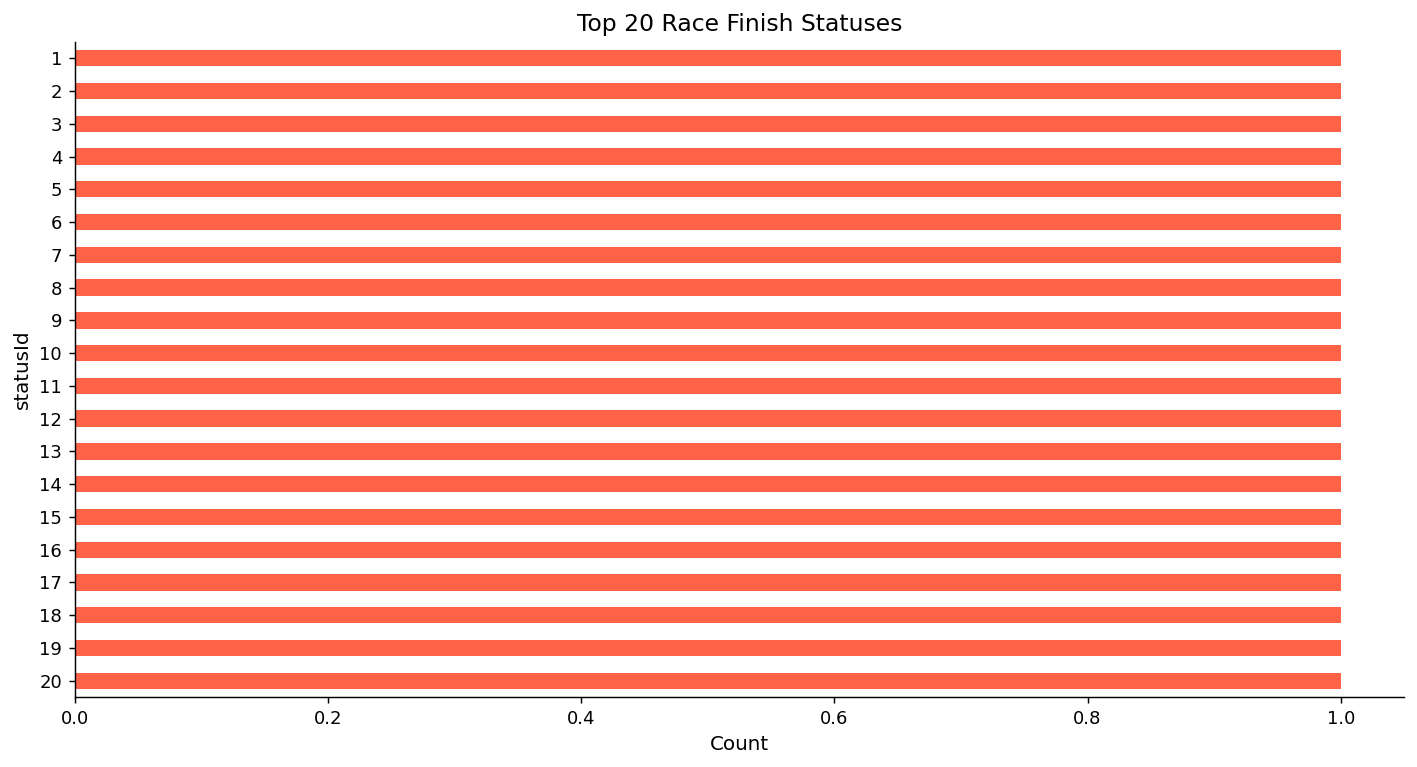

In [17]:
# ── Status frequency distribution ─────────────────────────────────────────────
status_col = [c for c in status.columns if 'status' in c.lower()]
if status_col:
    # If there's a count column use it, else count rows
    count_col = [c for c in status.columns if 'count' in c.lower() or 'freq' in c.lower()]
    if count_col:
        top_status = status.set_index(status_col[0])[count_col[0]].sort_values(ascending=False).head(20)
    else:
        top_status = status[status_col[0]].value_counts().head(20)

    fig, ax = plt.subplots(figsize=(11, 6))
    top_status.plot(kind='barh', ax=ax, color='tomato')
    ax.set_title('Top 20 Race Finish Statuses')
    ax.set_xlabel('Count')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '6_status_distribution.png', bbox_inches='tight')
    plt.show()

---
## 7. Cleaned Results

In [18]:
print('=== Results — Info ===')
print(results.dtypes)
print()
print(results.describe())

=== Results — Info ===
resultId             int64
raceId               int64
driverId             int64
constructorId        int64
number               int64
grid                 int64
position             int64
positionText        object
positionOrder        int64
points             float64
laps                 int64
time                object
milliseconds         int64
fastestLap           int64
rank                 int64
fastestLapTime      object
fastestLapSpeed    float64
statusId             int64
dtype: object

           resultId        raceId      driverId  constructorId        number  \
count  23777.000000  23777.000000  23777.000000   23777.000000  23777.000000   
mean   11889.481053    487.203937    226.515961      46.281785     16.961181   
std     6864.691322    269.904857    231.386102      56.174091     13.645737   
min        1.000000      1.000000      1.000000       1.000000      0.000000   
25%     5945.000000    273.000000     55.000000       6.000000      7.000000

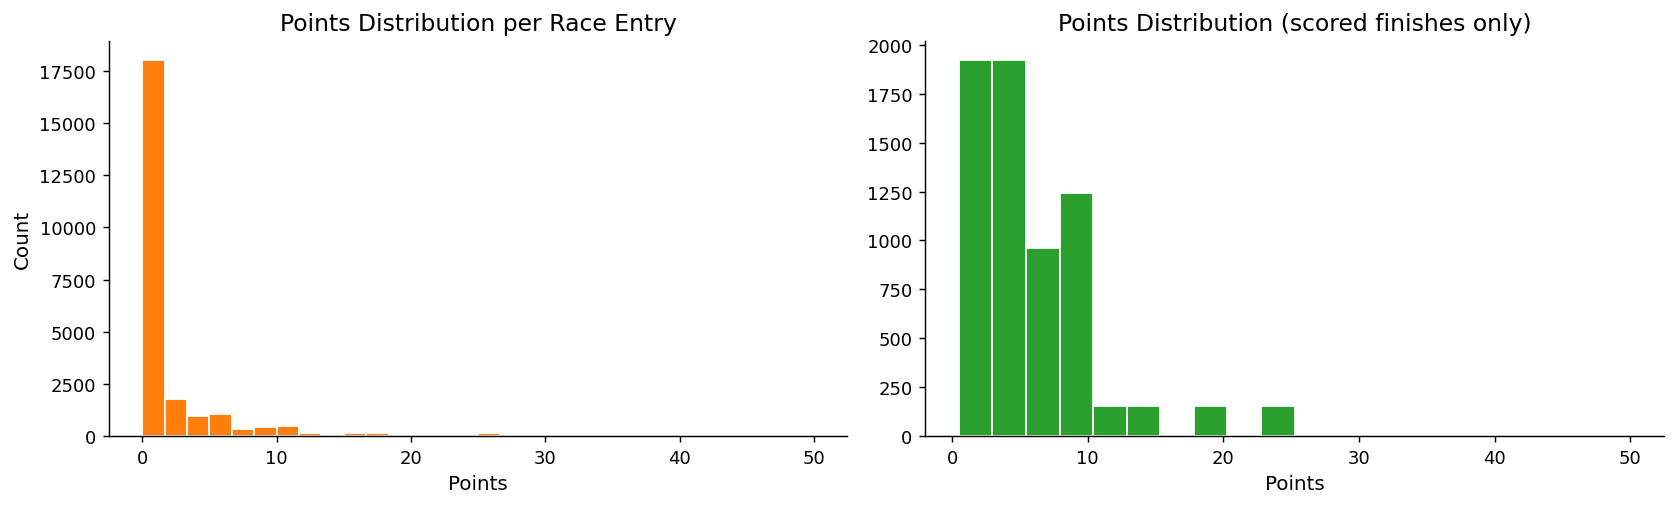

Zero-point finishes: 17,097 (71.9%)


In [19]:
# ── Points distribution ───────────────────────────────────────────────────────
pts_col = [c for c in results.columns if 'point' in c.lower()]
if pts_col:
    pts = pd.to_numeric(results[pts_col[0]], errors='coerce').dropna()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(pts, bins=30, color=COLORS[1], edgecolor='white')
    axes[0].set_title('Points Distribution per Race Entry')
    axes[0].set_xlabel('Points')
    axes[0].set_ylabel('Count')

    # Points > 0 only
    pts_pos = pts[pts > 0]
    axes[1].hist(pts_pos, bins=20, color=COLORS[2], edgecolor='white')
    axes[1].set_title('Points Distribution (scored finishes only)')
    axes[1].set_xlabel('Points')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '7_points_distribution.png', bbox_inches='tight')
    plt.show()
    print(f'Zero-point finishes: {(pts == 0).sum():,} ({(pts == 0).mean()*100:.1f}%)')

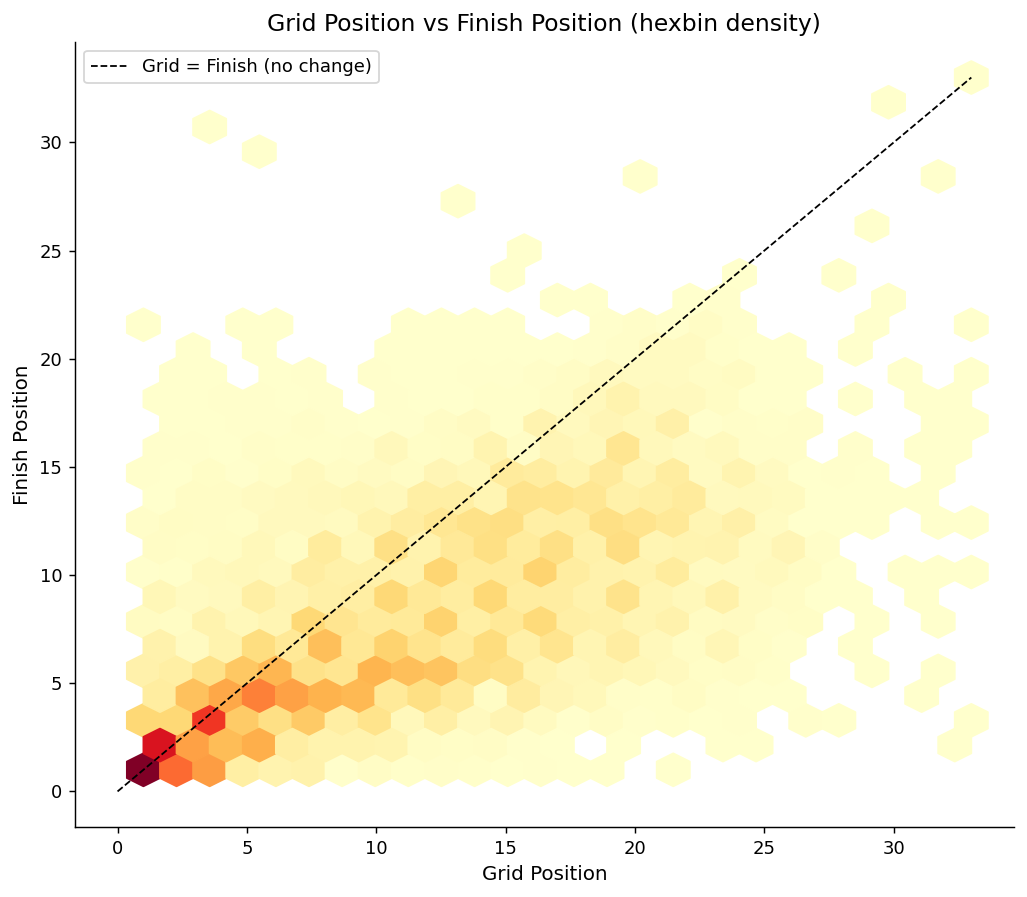

Pearson r (grid vs finish): 0.651


In [20]:
# ── Grid vs Finish position scatter ───────────────────────────────────────────
grid_col   = [c for c in results.columns if 'grid' in c.lower()]
finish_col = [c for c in results.columns if 'posit' in c.lower() or 'finish' in c.lower()]

if grid_col and finish_col:
    g = pd.to_numeric(results[grid_col[0]], errors='coerce')
    f = pd.to_numeric(results[finish_col[0]], errors='coerce')
    valid = pd.DataFrame({'grid': g, 'finish': f}).dropna()
    valid = valid[(valid['grid'] > 0) & (valid['finish'] > 0)]

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.hexbin(valid['grid'], valid['finish'], gridsize=25, cmap='YlOrRd', mincnt=1)
    ax.plot([0, valid['grid'].max()], [0, valid['grid'].max()],
            'k--', linewidth=1, label='Grid = Finish (no change)')
    ax.set_title('Grid Position vs Finish Position (hexbin density)')
    ax.set_xlabel('Grid Position')
    ax.set_ylabel('Finish Position')
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '7_grid_vs_finish.png', bbox_inches='tight')
    plt.show()

    corr = valid['grid'].corr(valid['finish'])
    print(f'Pearson r (grid vs finish): {corr:.3f}')

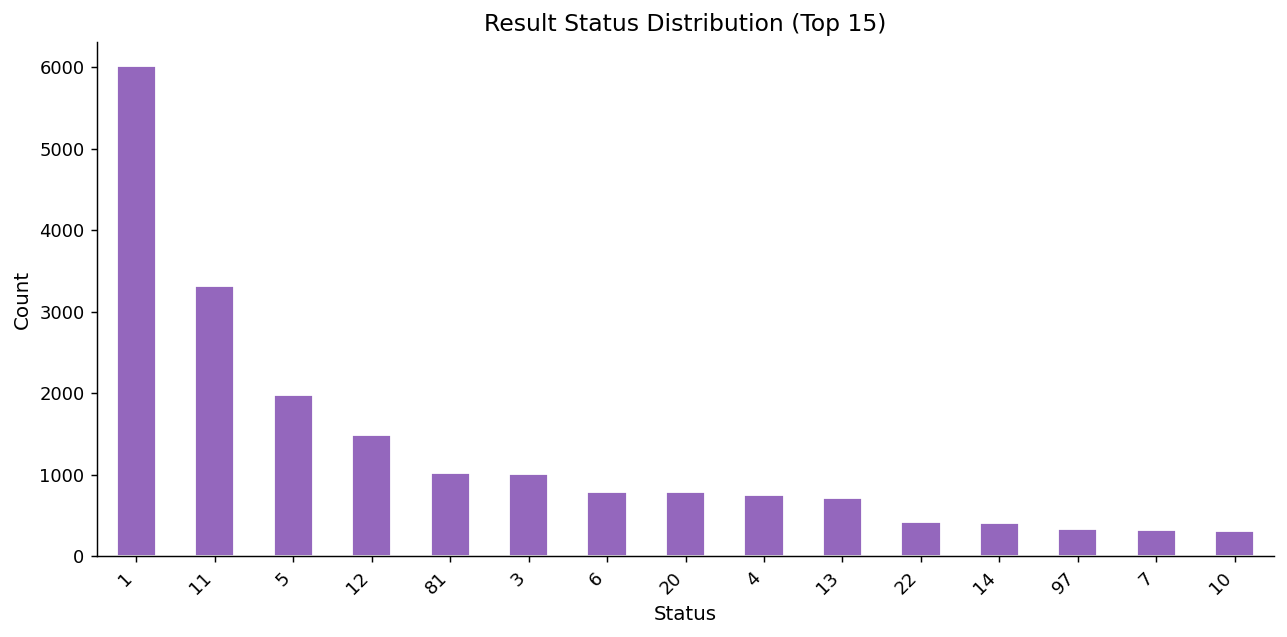

In [21]:
# ── DNF / finish status breakdown ─────────────────────────────────────────────
# look for a status or dnf column in results
status_r = [c for c in results.columns if 'status' in c.lower() or 'dnf' in c.lower()]
if status_r:
    sc = results[status_r[0]].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 5))
    sc.plot(kind='bar', ax=ax, color=COLORS[4], edgecolor='white')
    ax.set_title('Result Status Distribution (Top 15)')
    ax.set_xlabel('Status')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '7_result_status.png', bbox_inches='tight')
    plt.show()

---
## 8. Constructors

In [22]:
print('=== Constructors — Info ===')
print(constructors.dtypes)
print()
print(f'Total constructors: {len(constructors):,}')
print(constructors.head(10))

=== Constructors — Info ===
constructorId      int64
constructorRef    object
name              object
nationality       object
dtype: object

Total constructors: 208
   constructorId constructorRef         name nationality
0              1        mclaren      McLaren     British
1              2     bmw_sauber   BMW Sauber      German
2              3       williams     Williams     British
3              4        renault      Renault      French
4              5     toro_rosso   Toro Rosso     Italian
5              6        ferrari      Ferrari     Italian
6              7         toyota       Toyota    Japanese
7              8    super_aguri  Super Aguri    Japanese
8              9       red_bull     Red Bull    Austrian
9             10    force_india  Force India      Indian


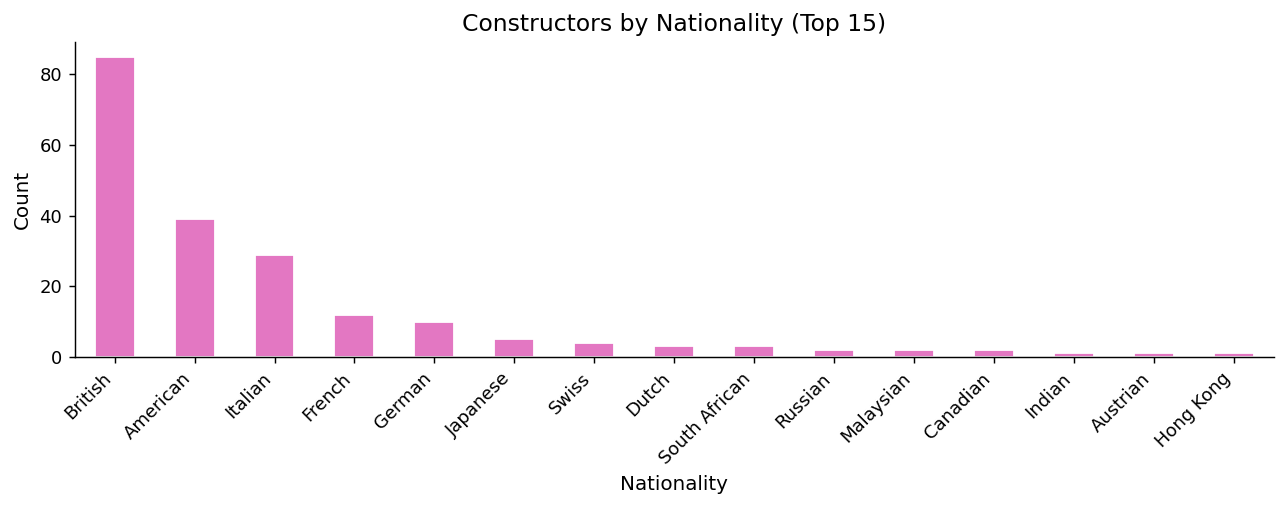

In [23]:
# ── Constructors by nationality ────────────────────────────────────────────────
nat_c = [c for c in constructors.columns if 'nation' in c.lower()]
if nat_c:
    cn = constructors[nat_c[0]].value_counts().head(15)
    fig, ax = plt.subplots(figsize=(10, 4))
    cn.plot(kind='bar', ax=ax, color=COLORS[6], edgecolor='white')
    ax.set_title('Constructors by Nationality (Top 15)')
    ax.set_xlabel('Nationality')
    ax.set_ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '8_constructor_nationality.png', bbox_inches='tight')
    plt.show()

---
## 9. Constructor Results

In [24]:
print('=== Constructor Results — Info ===')
print(con_results.dtypes)
print()
print(con_results.describe())

=== Constructor Results — Info ===
constructorResultsId    int64
raceId                  int64
constructorId           int64
points                  int64
dtype: object

       constructorResultsId        raceId  constructorId        points
count          11142.000000  11142.000000   11142.000000  11142.000000
mean            7364.008616    456.399479      41.252378      3.192066
std             5175.205274    261.142210      52.778298      6.406838
min                1.000000      1.000000       1.000000      0.000000
25%             2786.250000    259.250000       6.000000      0.000000
50%             5571.500000    440.000000      23.000000      0.000000
75%            12822.750000    628.000000      50.000000      4.000000
max            15639.000000    988.000000     210.000000     66.000000


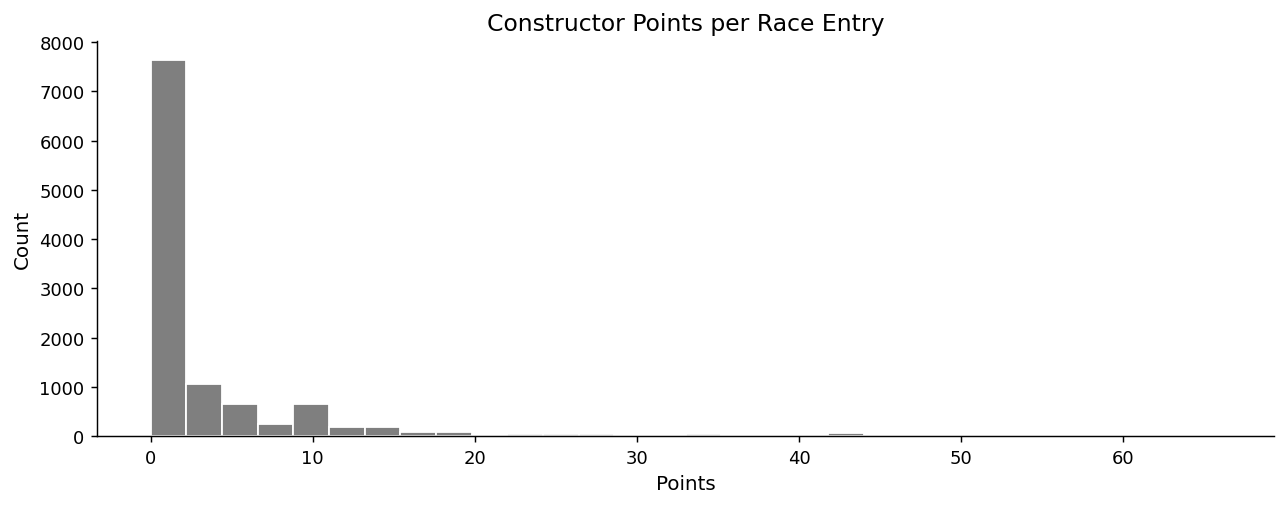

count    11142.000000
mean         3.192066
std          6.406838
min          0.000000
25%          0.000000
50%          0.000000
75%          4.000000
max         66.000000
Name: points, dtype: float64


In [25]:
# ── Points distribution ───────────────────────────────────────────────────────
cr_pts = [c for c in con_results.columns if 'point' in c.lower()]
if cr_pts:
    p = pd.to_numeric(con_results[cr_pts[0]], errors='coerce').dropna()
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.hist(p, bins=30, color=COLORS[7], edgecolor='white')
    ax.set_title('Constructor Points per Race Entry')
    ax.set_xlabel('Points')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '9_constructor_results_points.png', bbox_inches='tight')
    plt.show()
    print(p.describe())

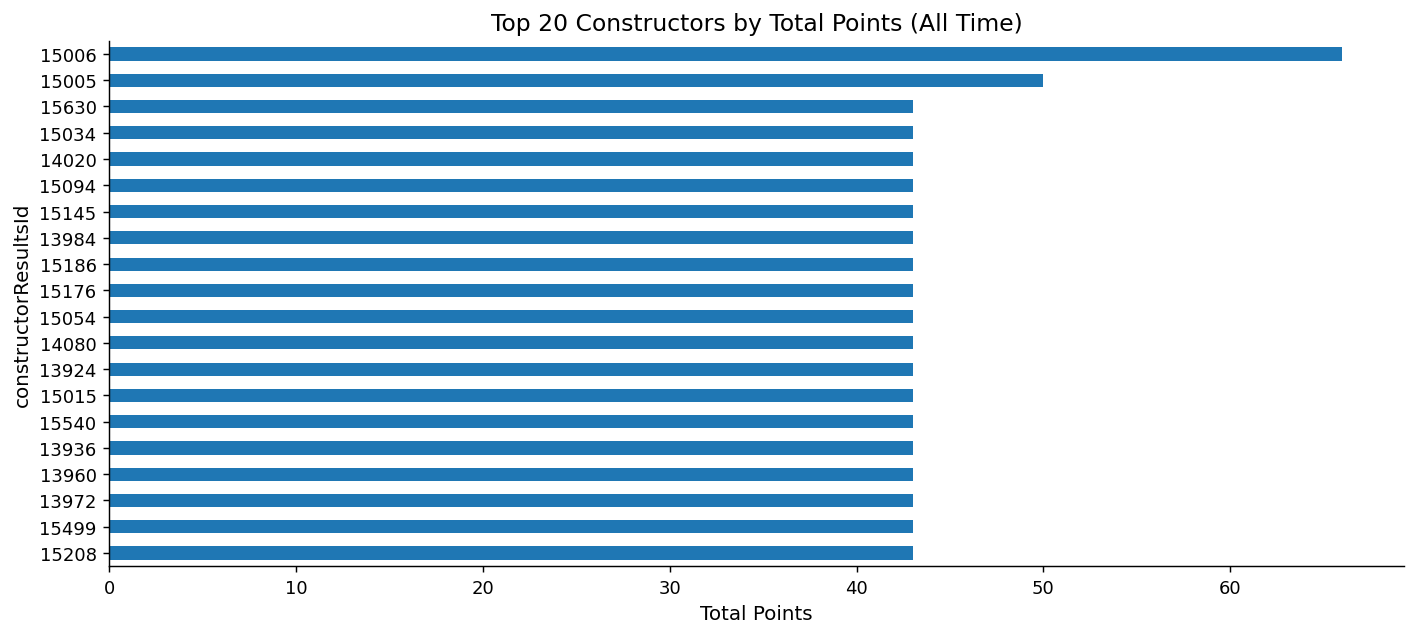

In [26]:
# ── Top constructors by total points (all time) ────────────────────────────────
cid_col = [c for c in con_results.columns if 'constructor' in c.lower() and 'id' in c.lower()]
if cr_pts and cid_col:
    top_con = (
        con_results
        .assign(pts=pd.to_numeric(con_results[cr_pts[0]], errors='coerce'))
        .groupby(cid_col[0])['pts']
        .sum()
        .sort_values(ascending=False)
        .head(20)
    )
    fig, ax = plt.subplots(figsize=(11, 5))
    top_con.plot(kind='barh', ax=ax, color=COLORS[0])
    ax.set_title('Top 20 Constructors by Total Points (All Time)')
    ax.set_xlabel('Total Points')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '9_top_constructors_all_time.png', bbox_inches='tight')
    plt.show()

---
## 10. Constructor Standings

In [27]:
print('=== Constructor Standings — Info ===')
print(con_standings.dtypes)
print()
print(con_standings.describe())

=== Constructor Standings — Info ===
constructorStandingsId     int64
raceId                     int64
constructorId              int64
points                     int64
position                   int64
positionText              object
wins                       int64
is_classified               bool
dtype: object

       constructorStandingsId        raceId  constructorId        points  \
count            11896.000000  11896.000000   11896.000000  11896.000000   
mean             15200.860121    469.105834      45.665518     27.138534   
std               8492.500051    257.949314      55.743913     62.874272   
min                  1.000000      1.000000       1.000000      0.000000   
25%               8244.750000    274.000000       6.000000      0.000000   
50%              17760.500000    463.000000      25.000000      6.000000   
75%              23302.250000    658.000000      56.000000     25.000000   
max              26932.000000    988.000000     210.000000    765.000000   


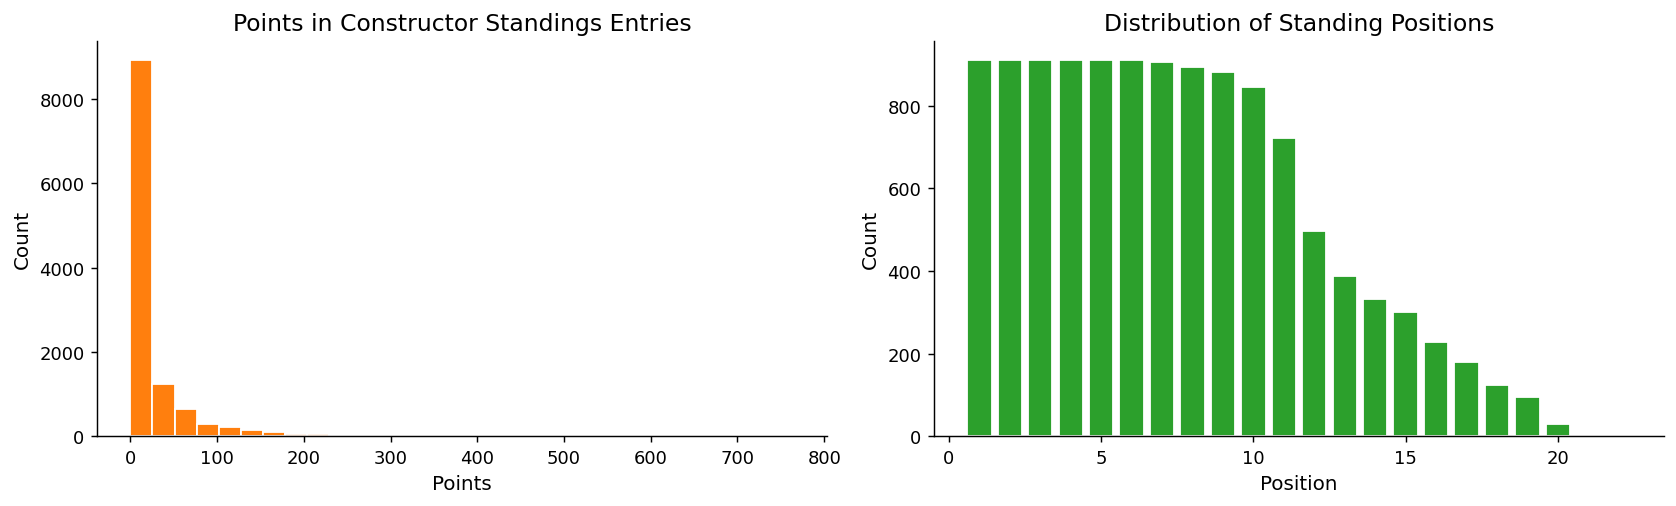

In [28]:
# ── Points distribution in standings ─────────────────────────────────────────
cs_pts = [c for c in con_standings.columns if 'point' in c.lower()]
cs_pos = [c for c in con_standings.columns if 'posit' in c.lower() or 'rank' in c.lower()]

if cs_pts:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    p = pd.to_numeric(con_standings[cs_pts[0]], errors='coerce').dropna()
    axes[0].hist(p, bins=30, color=COLORS[1], edgecolor='white')
    axes[0].set_title('Points in Constructor Standings Entries')
    axes[0].set_xlabel('Points')
    axes[0].set_ylabel('Count')

    if cs_pos:
        pos = pd.to_numeric(con_standings[cs_pos[0]], errors='coerce').dropna()
        pos_counts = pos.value_counts().sort_index()
        axes[1].bar(pos_counts.index, pos_counts.values, color=COLORS[2], edgecolor='white')
        axes[1].set_title('Distribution of Standing Positions')
        axes[1].set_xlabel('Position')
        axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '10_constructor_standings.png', bbox_inches='tight')
    plt.show()

Wins column stats:
count    11896.000000
mean         0.644334
std          1.723565
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max         19.000000
Name: wins, dtype: float64


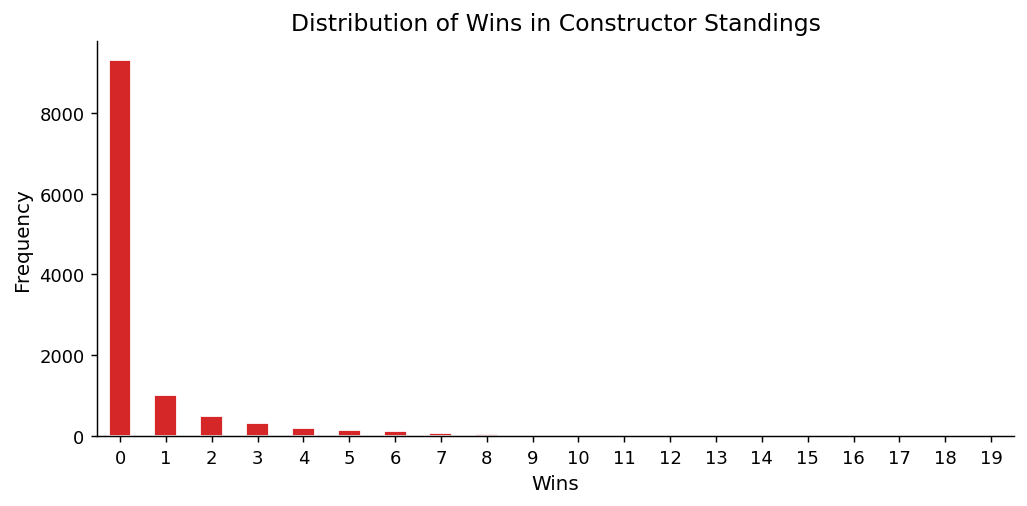

In [29]:
# ── Wins column analysis ──────────────────────────────────────────────────────
wins_col = [c for c in con_standings.columns if 'win' in c.lower()]
if wins_col:
    wins = pd.to_numeric(con_standings[wins_col[0]], errors='coerce').dropna()
    print('Wins column stats:')
    print(wins.describe())
    fig, ax = plt.subplots(figsize=(8, 4))
    wins.value_counts().sort_index().plot(kind='bar', ax=ax, color=COLORS[3], edgecolor='white')
    ax.set_title('Distribution of Wins in Constructor Standings')
    ax.set_xlabel('Wins')
    ax.set_ylabel('Frequency')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(FIG_DIR / '10_constructor_wins_distribution.png', bbox_inches='tight')
    plt.show()

---
## 11. Driver Standings

In [30]:
print('=== Driver Standings — Info ===')
print(drv_standings.dtypes)
print()
print(drv_standings.describe())

=== Driver Standings — Info ===
driverStandingsId     int64
raceId                int64
driverId              int64
points                int64
position              int64
positionText         object
wins                  int64
is_classified          bool
dtype: object

       driverStandingsId        raceId      driverId        points  \
count       31726.000000  31726.000000  31726.000000  31726.000000   
mean        39545.294806    537.923438    280.237944     10.620154   
std         21234.446977    261.533662    241.105400     28.817751   
min             1.000000      1.000000      1.000000      0.000000   
25%         18503.250000    329.000000     84.000000      0.000000   
50%         47758.500000    566.000000    205.000000      0.000000   
75%         56741.750000    769.000000    437.000000      8.000000   
max         68608.000000    988.000000    843.000000    397.000000   

           position          wins  
count  31726.000000  31726.000000  
mean      20.571361      0

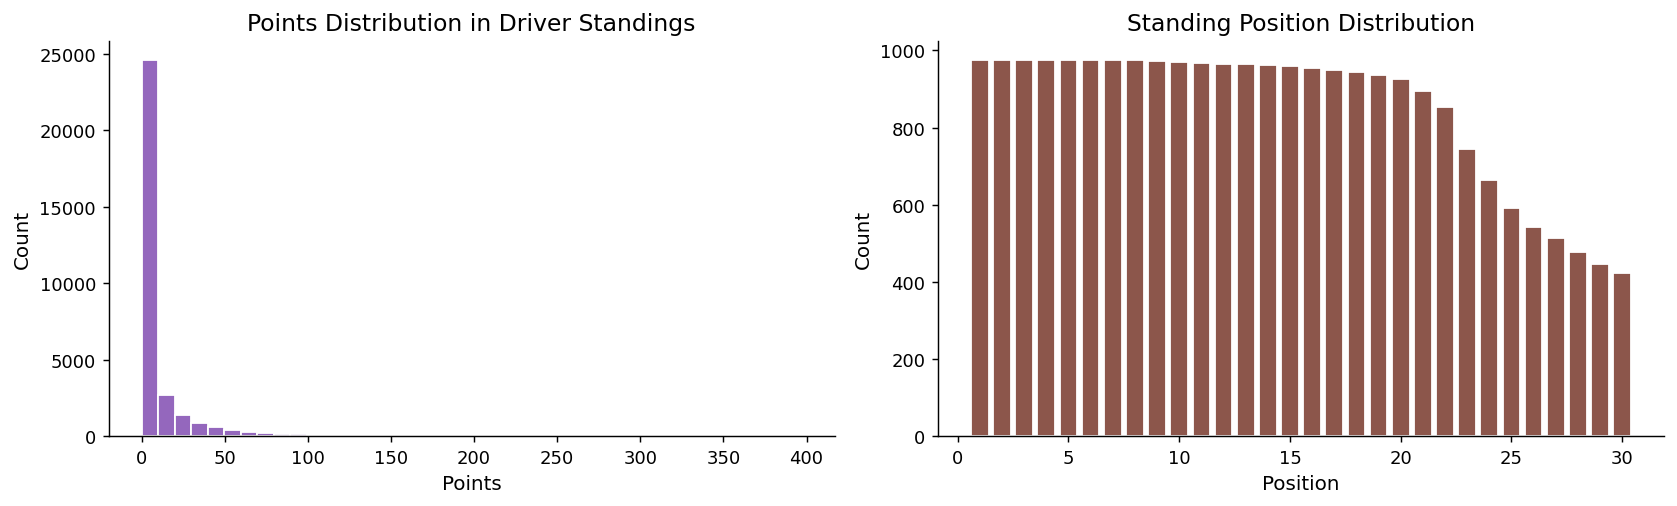

In [31]:
# ── Points & position distributions ───────────────────────────────────────────
ds_pts = [c for c in drv_standings.columns if 'point' in c.lower()]
ds_pos = [c for c in drv_standings.columns if 'posit' in c.lower() or 'rank' in c.lower()]

if ds_pts:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    p = pd.to_numeric(drv_standings[ds_pts[0]], errors='coerce').dropna()
    axes[0].hist(p, bins=40, color=COLORS[4], edgecolor='white')
    axes[0].set_title('Points Distribution in Driver Standings')
    axes[0].set_xlabel('Points')
    axes[0].set_ylabel('Count')

    if ds_pos:
        pos = pd.to_numeric(drv_standings[ds_pos[0]], errors='coerce').dropna()
        pos_counts = pos.value_counts().sort_index().head(30)
        axes[1].bar(pos_counts.index, pos_counts.values, color=COLORS[5], edgecolor='white')
        axes[1].set_title('Standing Position Distribution')
        axes[1].set_xlabel('Position')
        axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '11_driver_standings.png', bbox_inches='tight')
    plt.show()

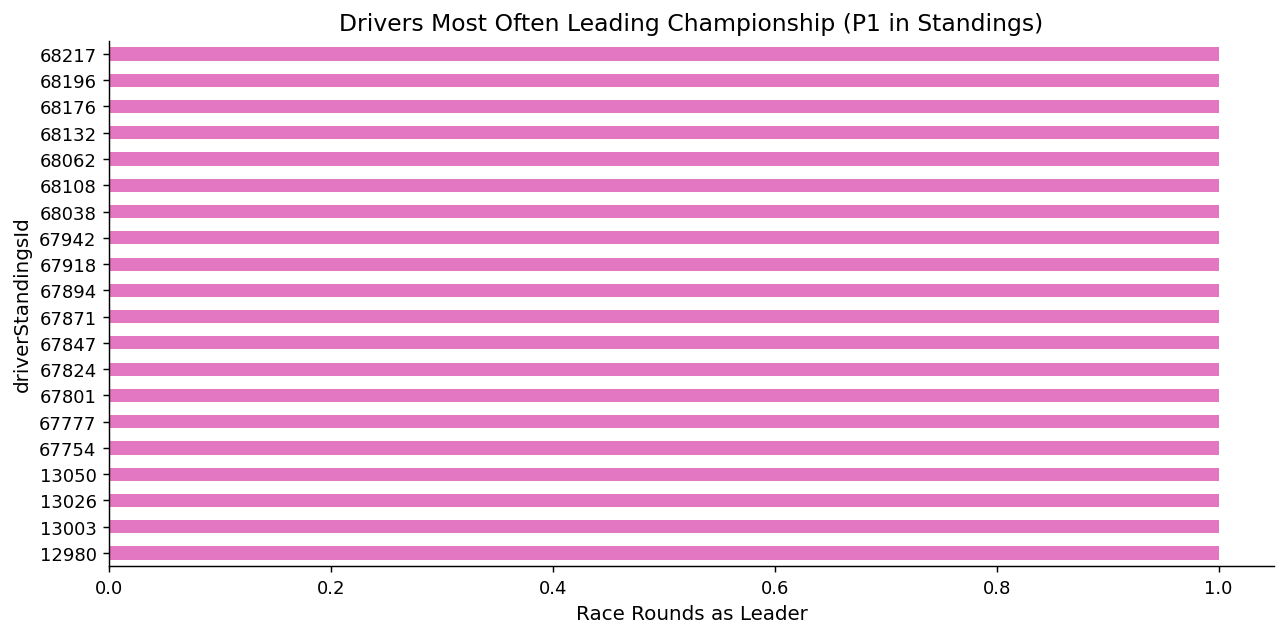

In [32]:
# ── Drivers with the most championship leader appearances ─────────────────────
ds_drv = [c for c in drv_standings.columns if 'driver' in c.lower() and 'id' in c.lower()]
if ds_drv and ds_pos:
    leaders = drv_standings[pd.to_numeric(drv_standings[ds_pos[0]], errors='coerce') == 1]
    top_leaders = leaders[ds_drv[0]].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(10, 5))
    top_leaders.plot(kind='barh', ax=ax, color=COLORS[6])
    ax.set_title('Drivers Most Often Leading Championship (P1 in Standings)')
    ax.set_xlabel('Race Rounds as Leader')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '11_championship_leaders.png', bbox_inches='tight')
    plt.show()

---
## 12. Qualifying

In [33]:
print('=== Qualifying — Info ===')
print(qualifying.dtypes)
print()
print(qualifying.describe())
print()
print('Missing values:')
print(qualifying.isnull().sum())

=== Qualifying — Info ===
qualifyId         int64
raceId            int64
driverId          int64
constructorId     int64
number            int64
position          int64
q1               object
q2               object
q3               object
dtype: object

         qualifyId       raceId     driverId  constructorId       number  \
count  7516.000000  7516.000000  7516.000000    7516.000000  7516.000000   
mean   3762.934939   449.830894   203.803752      34.757318    15.288318   
std    2175.400371   384.012280   325.034734      61.700784    14.057586   
min       1.000000     1.000000     1.000000       1.000000     0.000000   
25%    1879.750000    91.000000    14.000000       4.000000     7.000000   
50%    3759.500000   259.000000    30.000000       9.000000    12.000000   
75%    5639.250000   887.000000   111.000000      19.000000    20.000000   
max    7539.000000   988.000000   843.000000     210.000000    99.000000   

          position  
count  7516.000000  
mean     11.4735

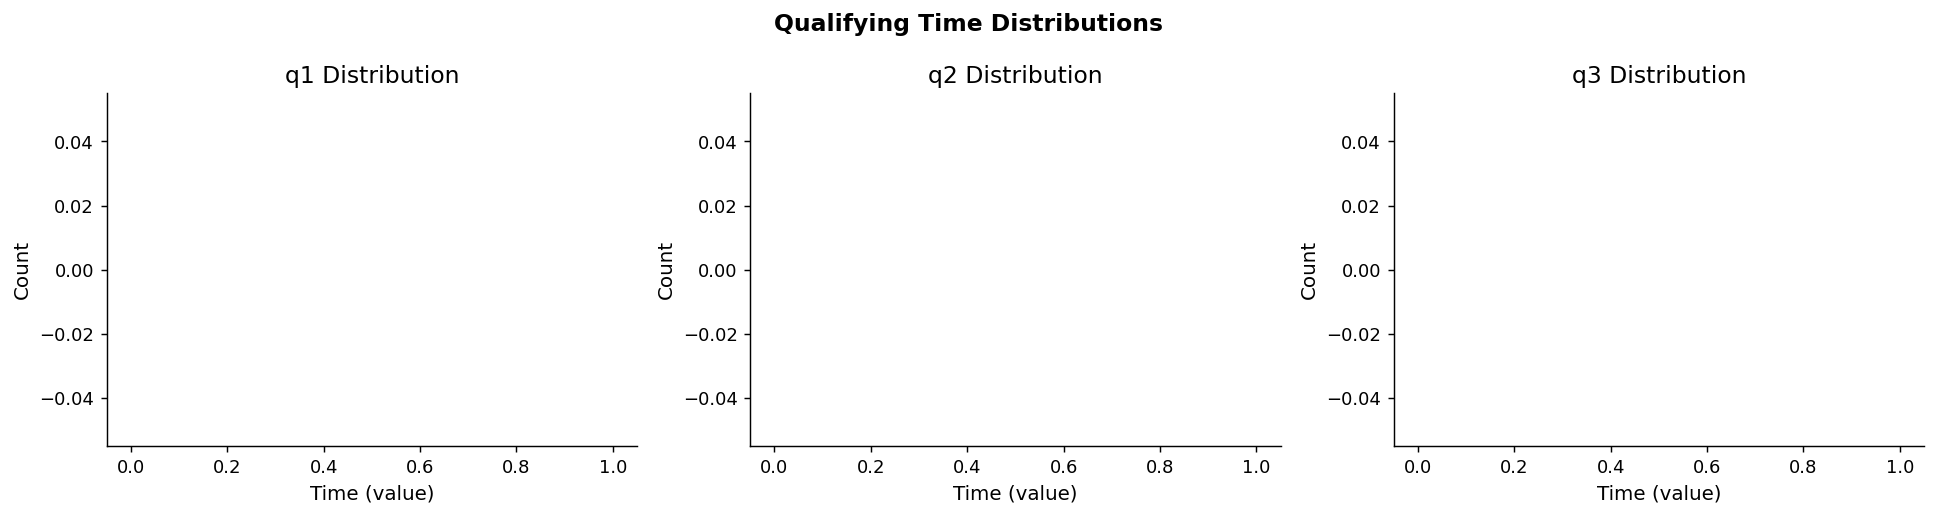

In [34]:
# ── Q1/Q2/Q3 time distributions ───────────────────────────────────────────────
q_cols = [c for c in qualifying.columns if c.lower() in ['q1', 'q2', 'q3'] or
          any(x in c.lower() for x in ['q1_', 'q2_', 'q3_', '_q1', '_q2', '_q3'])]

if q_cols:
    fig, axes = plt.subplots(1, len(q_cols), figsize=(5 * len(q_cols), 4))
    if len(q_cols) == 1:
        axes = [axes]
    for ax, col in zip(axes, q_cols):
        data = pd.to_numeric(qualifying[col], errors='coerce').dropna()
        # Convert ms to seconds if values are large
        if data.median() > 1000:
            data = data / 1000
            unit = 'seconds'
        else:
            unit = 'value'
        ax.hist(data, bins=40, color=COLORS[7], edgecolor='white')
        ax.set_title(f'{col} Distribution')
        ax.set_xlabel(f'Time ({unit})')
        ax.set_ylabel('Count')
    plt.suptitle('Qualifying Time Distributions', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '12_qualifying_times.png', bbox_inches='tight')
    plt.show()

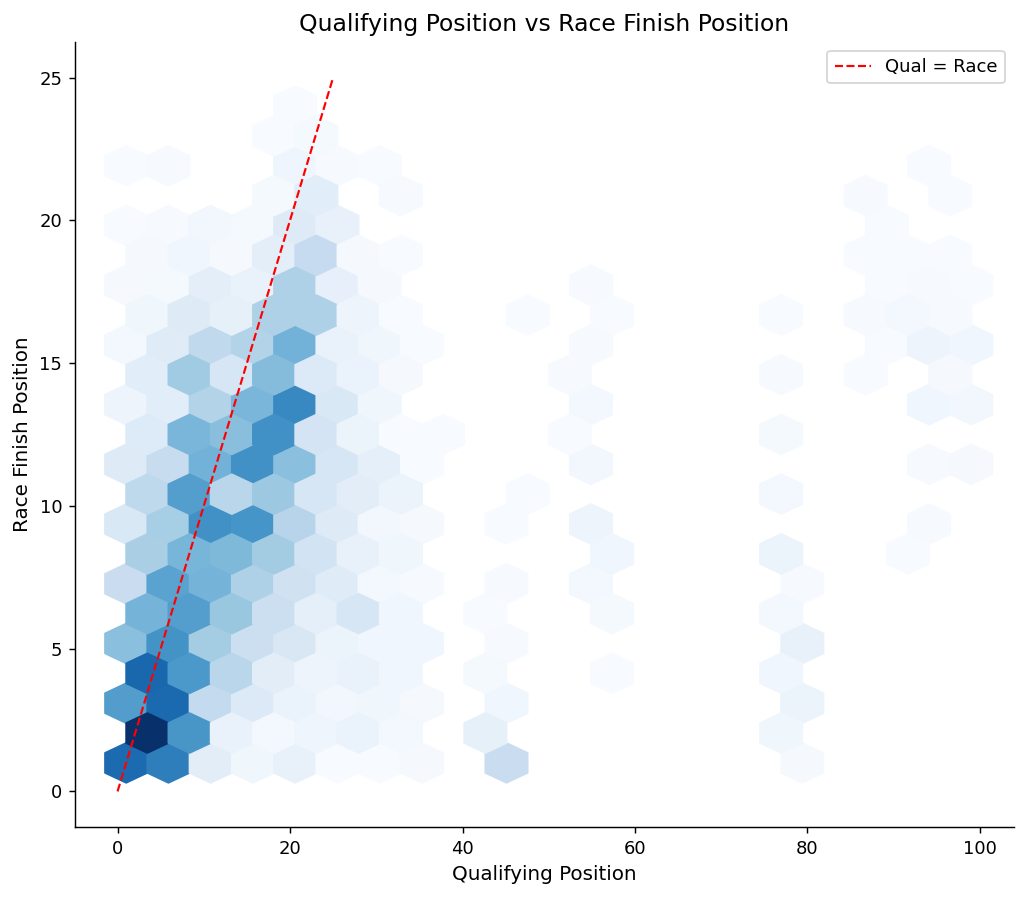

Correlation qual vs race position: 0.254


In [35]:
# ── Qualifying position vs Race position (if both available) ──────────────────
qual_pos = [c for c in qualifying.columns if 'posit' in c.lower() or 'number' in c.lower()]
if qual_pos:
    # Merge with results on raceId + driverId
    merge_cols = ['raceId', 'driverId'] if 'raceId' in qualifying.columns and 'driverId' in qualifying.columns else []
    if merge_cols and 'raceId' in results.columns and 'driverId' in results.columns:
        r_pos = [c for c in results.columns if 'posit' in c.lower()]
        if r_pos:
            merged = qualifying[merge_cols + qual_pos[:1]].merge(
                results[merge_cols + r_pos[:1]], on=merge_cols, how='inner'
            )
            x = pd.to_numeric(merged[qual_pos[0]], errors='coerce')
            y = pd.to_numeric(merged[r_pos[0]], errors='coerce')
            valid = pd.DataFrame({'qual': x, 'race': y}).dropna()
            valid = valid[(valid['qual'] > 0) & (valid['race'] > 0)]

            if len(valid) > 0:
                fig, ax = plt.subplots(figsize=(8, 7))
                ax.hexbin(valid['qual'], valid['race'], gridsize=20, cmap='Blues', mincnt=1)
                ax.plot([0, 25], [0, 25], 'r--', linewidth=1.2, label='Qual = Race')
                ax.set_title('Qualifying Position vs Race Finish Position')
                ax.set_xlabel('Qualifying Position')
                ax.set_ylabel('Race Finish Position')
                ax.legend()
                plt.tight_layout()
                plt.savefig(FIG_DIR / '12_qual_vs_race.png', bbox_inches='tight')
                plt.show()
                print(f'Correlation qual vs race position: {valid["qual"].corr(valid["race"]):.3f}')

---
## 13. Pit Stops

In [36]:
print('=== Pit Stops — Info ===')
print(pit_stops.dtypes)
print()
print(pit_stops.describe())
print()
print('Missing values:')
print(pit_stops.isnull().sum())

=== Pit Stops — Info ===
raceId            int64
driverId          int64
stop              int64
lap               int64
time             object
duration        float64
milliseconds      int64
dtype: object

            raceId     driverId         stop          lap     duration  \
count  6251.000000  6251.000000  6251.000000  6251.000000  6119.000000   
mean    907.860342   429.468245     1.836346    24.813470    24.142921   
std      44.327698   397.079565     0.935314    14.150022     4.367370   
min     841.000000     1.000000     1.000000     1.000000    12.897000   
25%     868.000000    13.000000     1.000000    13.000000    21.722000   
50%     902.000000   807.000000     2.000000    24.000000    23.263000   
75%     950.000000   821.000000     2.000000    35.000000    25.333000   
max     988.000000   843.000000     6.000000    74.000000    59.555000   

       milliseconds  
count  6.251000e+03  
mean   4.774453e+04  
std    1.791970e+05  
min    1.289700e+04  
25%    2.176800

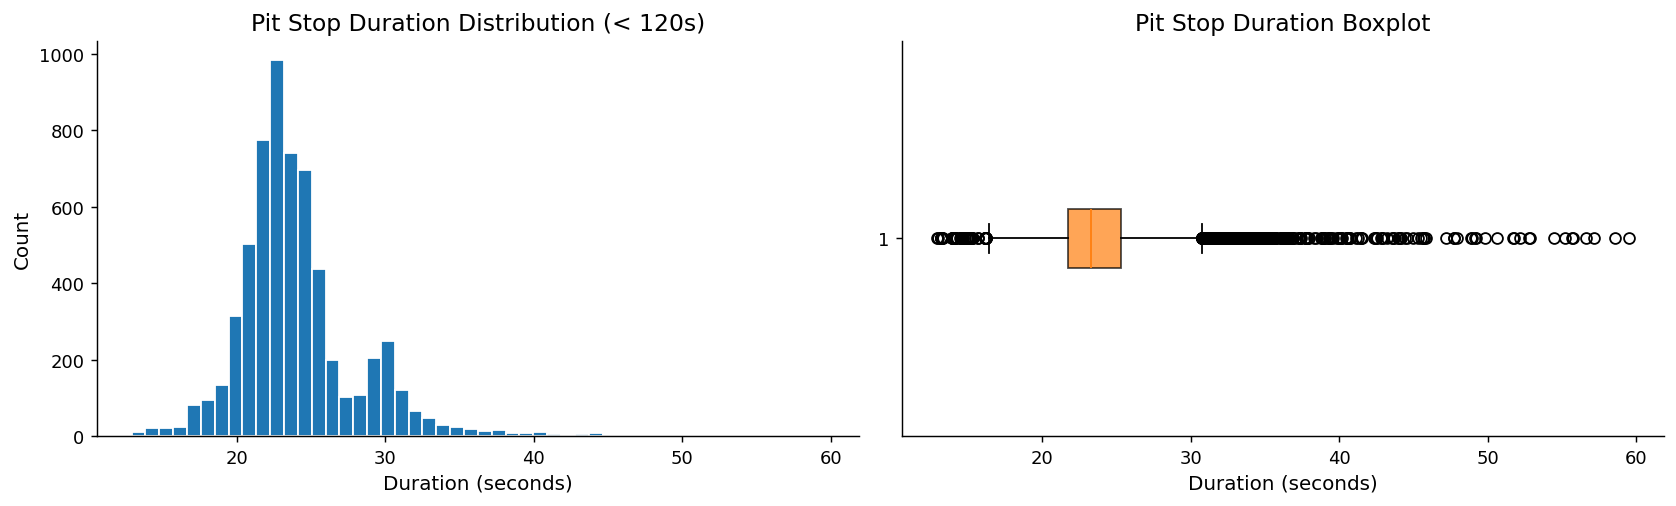

count    6119.000000
mean       24.142921
std         4.367370
min        12.897000
25%        21.722000
50%        23.263000
75%        25.333000
max        59.555000
Name: duration, dtype: float64


In [37]:
# ── Pit stop duration distribution ────────────────────────────────────────────
dur_col = [c for c in pit_stops.columns if 'duration' in c.lower() or 'millisecond' in c.lower() or 'ms' in c.lower()]
if dur_col:
    dur = pd.to_numeric(pit_stops[dur_col[0]], errors='coerce').dropna()
    # Convert to seconds if in ms
    if dur.median() > 1000:
        dur = dur / 1000
    # Remove outliers (>120 seconds)
    dur_clean = dur[dur < 120]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(dur_clean, bins=50, color=COLORS[0], edgecolor='white')
    axes[0].set_title('Pit Stop Duration Distribution (< 120s)')
    axes[0].set_xlabel('Duration (seconds)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(dur_clean, vert=False, patch_artist=True,
                    boxprops=dict(facecolor=COLORS[1], alpha=0.7))
    axes[1].set_title('Pit Stop Duration Boxplot')
    axes[1].set_xlabel('Duration (seconds)')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '13_pitstop_duration.png', bbox_inches='tight')
    plt.show()
    print(dur_clean.describe())

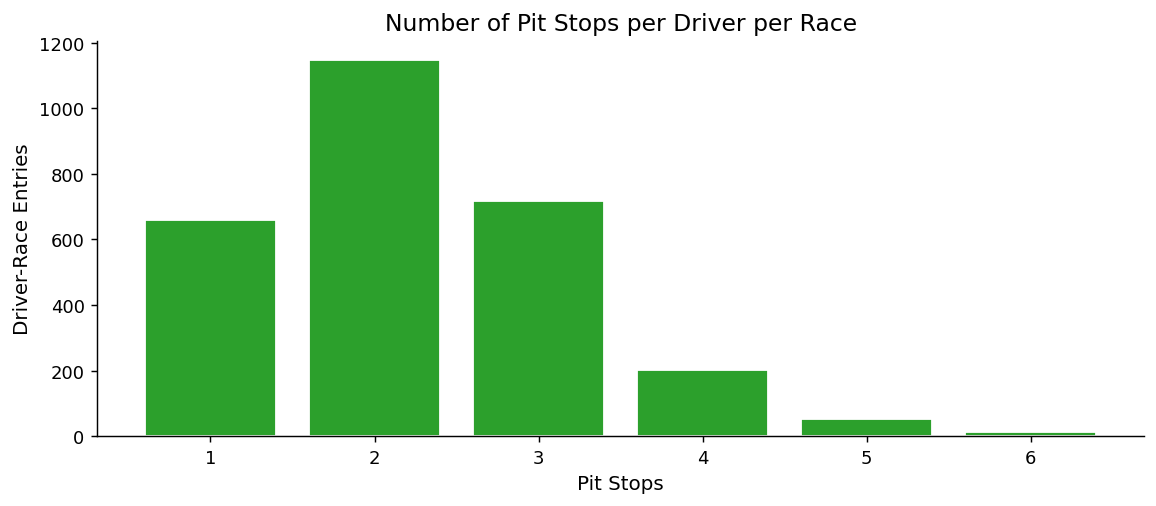

count    2790.000000
mean        2.240502
std         0.983482
min         1.000000
25%         2.000000
50%         2.000000
75%         3.000000
max         6.000000
Name: num_stops, dtype: float64


In [38]:
# ── Pit stops per race distribution ───────────────────────────────────────────
race_id_col = [c for c in pit_stops.columns if 'race' in c.lower() and 'id' in c.lower()]
drv_id_col  = [c for c in pit_stops.columns if 'driver' in c.lower() and 'id' in c.lower()]

if race_id_col and drv_id_col:
    stops_per_driver = pit_stops.groupby([race_id_col[0], drv_id_col[0]]).size().reset_index(name='num_stops')
    stop_counts = stops_per_driver['num_stops'].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(stop_counts.index, stop_counts.values, color=COLORS[2], edgecolor='white')
    ax.set_title('Number of Pit Stops per Driver per Race')
    ax.set_xlabel('Pit Stops')
    ax.set_ylabel('Driver-Race Entries')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '13_pitstop_count.png', bbox_inches='tight')
    plt.show()
    print(stops_per_driver['num_stops'].describe())

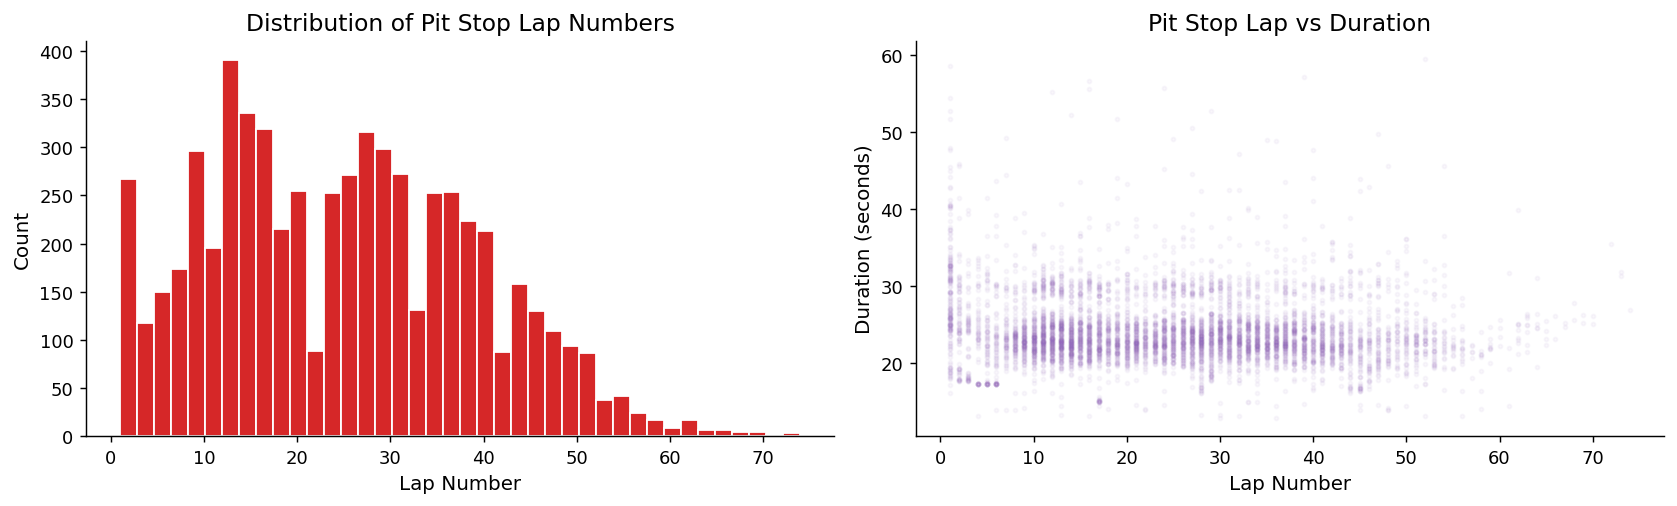

In [39]:
# ── Pit stop lap (when in the race) distribution ───────────────────────────────
lap_col = [c for c in pit_stops.columns if 'lap' in c.lower()]
if lap_col and dur_col:
    lap = pd.to_numeric(pit_stops[lap_col[0]], errors='coerce').dropna()
    dur2 = pd.to_numeric(pit_stops[dur_col[0]], errors='coerce')
    if dur2.median() > 1000:
        dur2 = dur2 / 1000

    combined = pd.DataFrame({'lap': lap, 'duration': dur2}).dropna()
    combined = combined[combined['duration'] < 120]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(combined['lap'], bins=40, color=COLORS[3], edgecolor='white')
    axes[0].set_title('Distribution of Pit Stop Lap Numbers')
    axes[0].set_xlabel('Lap Number')
    axes[0].set_ylabel('Count')

    axes[1].scatter(combined['lap'], combined['duration'], alpha=0.05, s=5, color=COLORS[4])
    axes[1].set_title('Pit Stop Lap vs Duration')
    axes[1].set_xlabel('Lap Number')
    axes[1].set_ylabel('Duration (seconds)')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '13_pitstop_lap_vs_duration.png', bbox_inches='tight')
    plt.show()

---
## 14. Lap Times

In [40]:
print('=== Lap Times — Info ===')
print(lap_times.dtypes)
print()
print(lap_times.describe())
print(f'\nTotal lap records: {len(lap_times):,}')

=== Lap Times — Info ===
raceId           int64
driverId         int64
lap              int64
position         int64
time            object
milliseconds     int64
lap_flag        object
dtype: object

              raceId       driverId            lap       position  \
count  426633.000000  426633.000000  426633.000000  426633.000000   
mean      423.120853     186.503817      29.827172       9.646896   
std       381.542422     316.123374      18.402245       5.580664   
min         1.000000       1.000000       1.000000       1.000000   
25%       100.000000      14.000000      14.000000       5.000000   
50%       205.000000      26.000000      29.000000       9.000000   
75%       881.000000      71.000000      44.000000      14.000000   
max       988.000000     843.000000      78.000000      24.000000   

       milliseconds  
count  4.266330e+05  
mean   9.580222e+04  
std    7.475541e+04  
min    6.741100e+04  
25%    8.238200e+04  
50%    9.080000e+04  
75%    1.027380e+05  
m

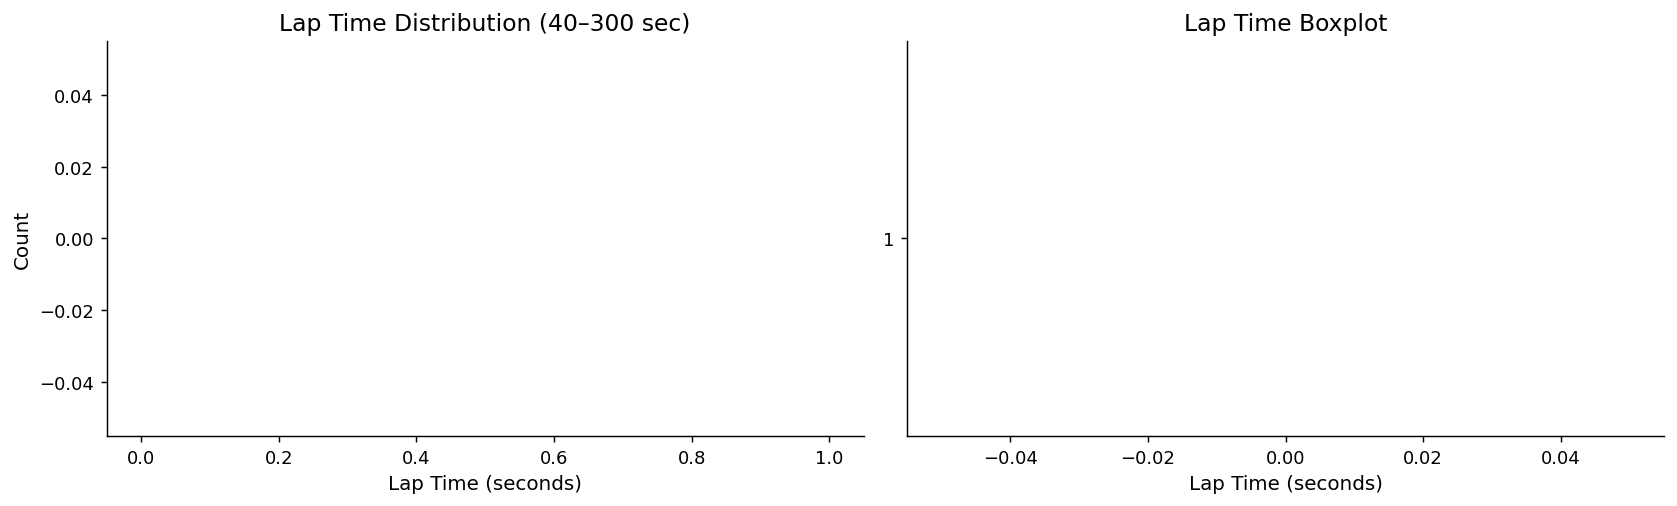

count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
Name: time, dtype: float64


In [41]:
# ── Lap time distribution ─────────────────────────────────────────────────────
lt_ms = [c for c in lap_times.columns if 'millisecond' in c.lower() or 'ms' in c.lower() or 'time' in c.lower()]
if lt_ms:
    lt = pd.to_numeric(lap_times[lt_ms[0]], errors='coerce').dropna()
    if lt.median() > 10000:
        lt = lt / 1000   # ms → seconds
    lt_clean = lt[(lt > 40) & (lt < 300)]  # filter extremes

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].hist(lt_clean, bins=60, color=COLORS[5], edgecolor='white')
    axes[0].set_title('Lap Time Distribution (40–300 sec)')
    axes[0].set_xlabel('Lap Time (seconds)')
    axes[0].set_ylabel('Count')

    axes[1].boxplot(lt_clean, vert=False, patch_artist=True,
                    boxprops=dict(facecolor=COLORS[6], alpha=0.7))
    axes[1].set_title('Lap Time Boxplot')
    axes[1].set_xlabel('Lap Time (seconds)')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '14_laptime_distribution.png', bbox_inches='tight')
    plt.show()
    print(lt_clean.describe())

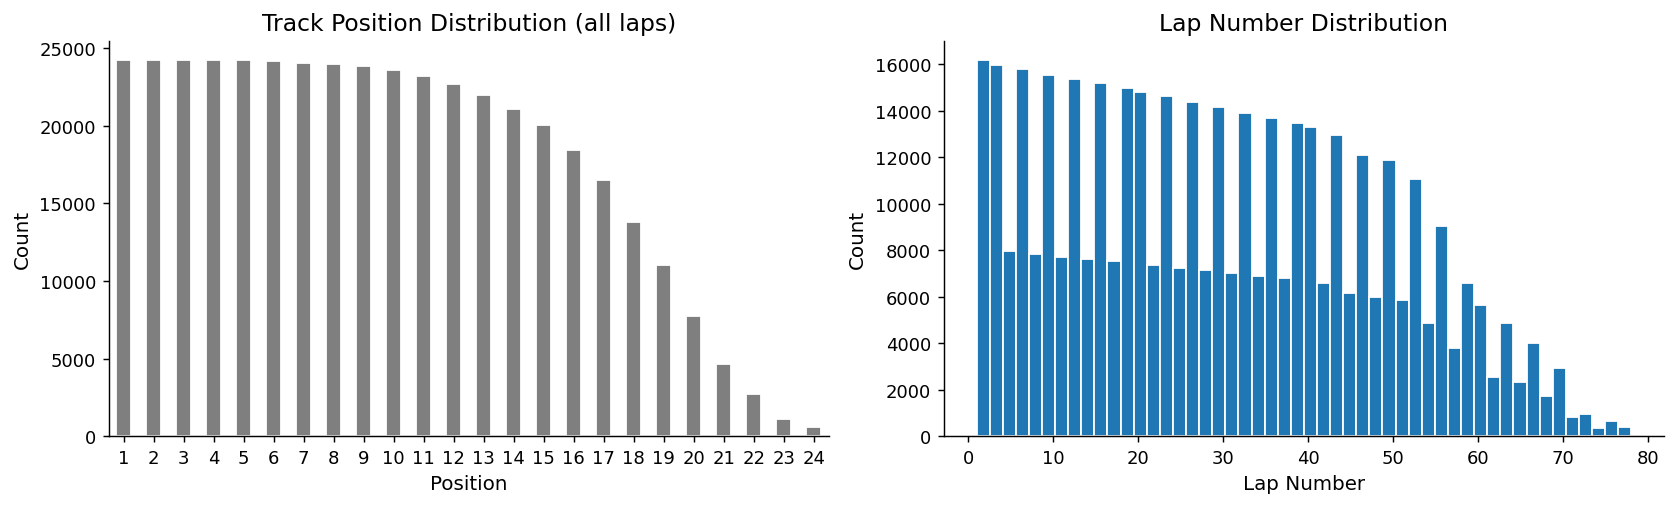

In [42]:
# ── Lap position (race order) distribution ────────────────────────────────────
lt_pos = [c for c in lap_times.columns if 'posit' in c.lower()]
lt_lap = [c for c in lap_times.columns if c.lower() == 'lap' or 'lapnumber' in c.lower() or 'lap_number' in c.lower()]

if lt_pos and lt_lap:
    pos = pd.to_numeric(lap_times[lt_pos[0]], errors='coerce').dropna()
    lap_num = pd.to_numeric(lap_times[lt_lap[0]], errors='coerce').dropna()

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    pos.value_counts().sort_index().head(30).plot(kind='bar', ax=axes[0], color=COLORS[7], edgecolor='white')
    axes[0].set_title('Track Position Distribution (all laps)')
    axes[0].set_xlabel('Position')
    axes[0].set_ylabel('Count')
    plt.setp(axes[0].get_xticklabels(), rotation=0)

    axes[1].hist(lap_num, bins=50, color=COLORS[0], edgecolor='white')
    axes[1].set_title('Lap Number Distribution')
    axes[1].set_xlabel('Lap Number')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.savefig(FIG_DIR / '14_lap_position.png', bbox_inches='tight')
    plt.show()

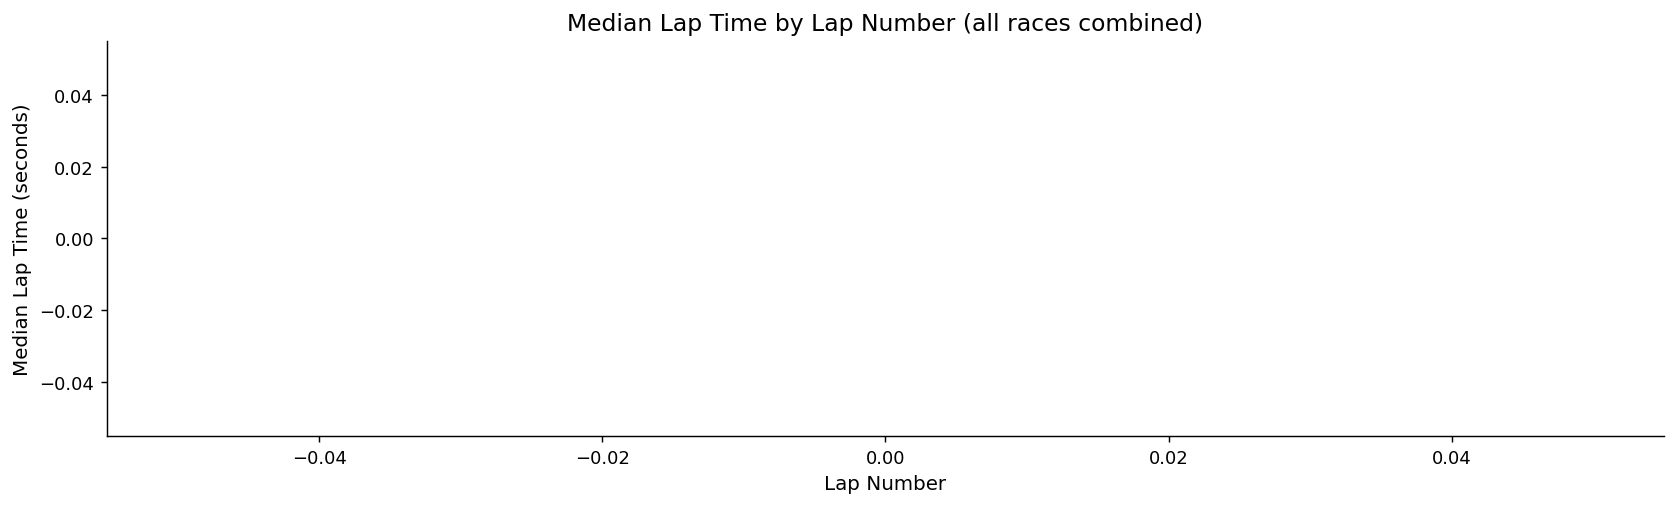

In [43]:
# ── Average lap time per lap number (stint degradation pattern) ────────────────
if lt_lap and lt_ms:
    lap_times['_lap'] = pd.to_numeric(lap_times[lt_lap[0]], errors='coerce')
    lap_times['_time'] = pd.to_numeric(lap_times[lt_ms[0]], errors='coerce')
    if lap_times['_time'].median() > 10000:
        lap_times['_time'] = lap_times['_time'] / 1000

    lap_times_clean = lap_times[
        (lap_times['_time'] > 40) & (lap_times['_time'] < 300) & (lap_times['_lap'] <= 80)
    ]
    avg_by_lap = lap_times_clean.groupby('_lap')['_time'].median()

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(avg_by_lap.index, avg_by_lap.values, color=COLORS[1], linewidth=1.5)
    ax.set_title('Median Lap Time by Lap Number (all races combined)')
    ax.set_xlabel('Lap Number')
    ax.set_ylabel('Median Lap Time (seconds)')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '14_avg_laptime_by_lap.png', bbox_inches='tight')
    plt.show()

---
## 15. Cross-Dataset Analysis

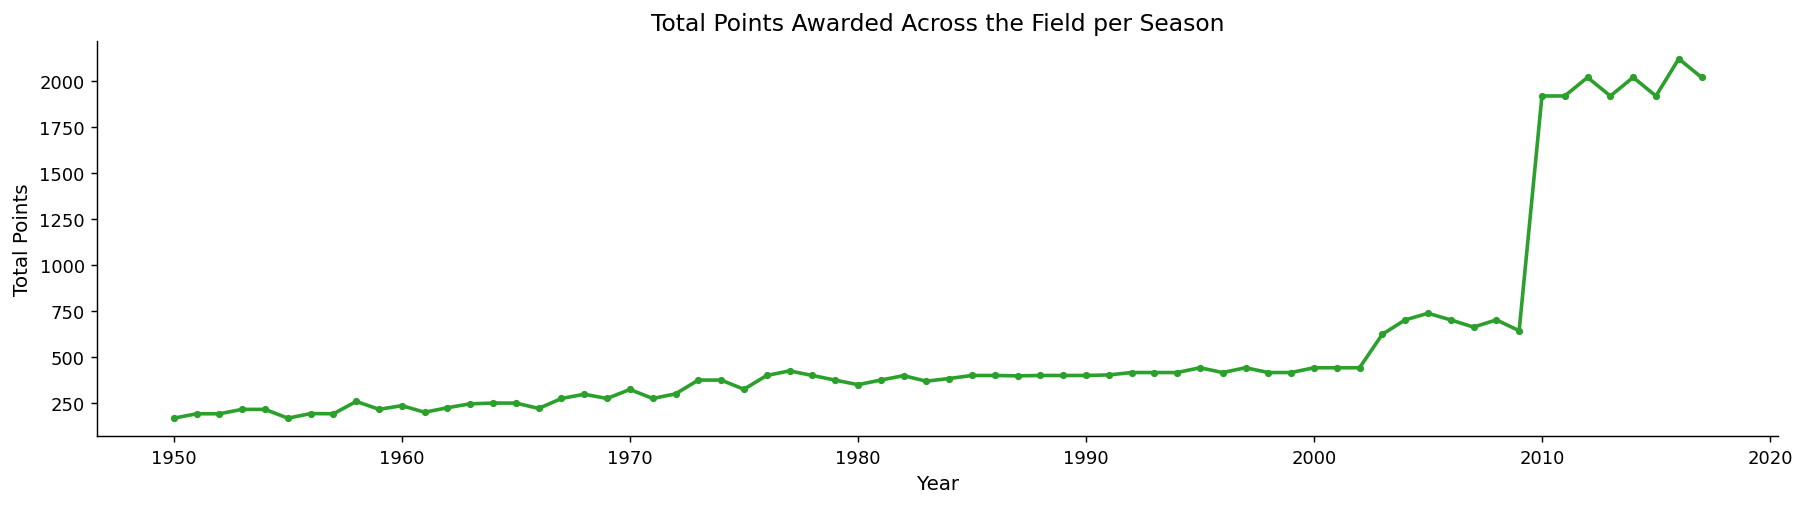

In [44]:
# ── Results + Races: Points scored per season (total field) ───────────────────
if 'raceId' in results.columns and 'raceId' in races.columns:
    yr_col = [c for c in races.columns if 'year' in c.lower()]
    pts_col2 = [c for c in results.columns if 'point' in c.lower()]
    if yr_col and pts_col2:
        merged_r = results.merge(races[[*( ['raceId'] + yr_col)]], on='raceId', how='left')
        merged_r['_pts'] = pd.to_numeric(merged_r[pts_col2[0]], errors='coerce')
        season_pts = merged_r.groupby(yr_col[0])['_pts'].sum()

        fig, ax = plt.subplots(figsize=(14, 4))
        ax.plot(season_pts.index, season_pts.values, color=COLORS[2], linewidth=2, marker='o', markersize=3)
        ax.set_title('Total Points Awarded Across the Field per Season')
        ax.set_xlabel('Year')
        ax.set_ylabel('Total Points')
        plt.tight_layout()
        plt.savefig(FIG_DIR / '15_total_points_per_season.png', bbox_inches='tight')
        plt.show()

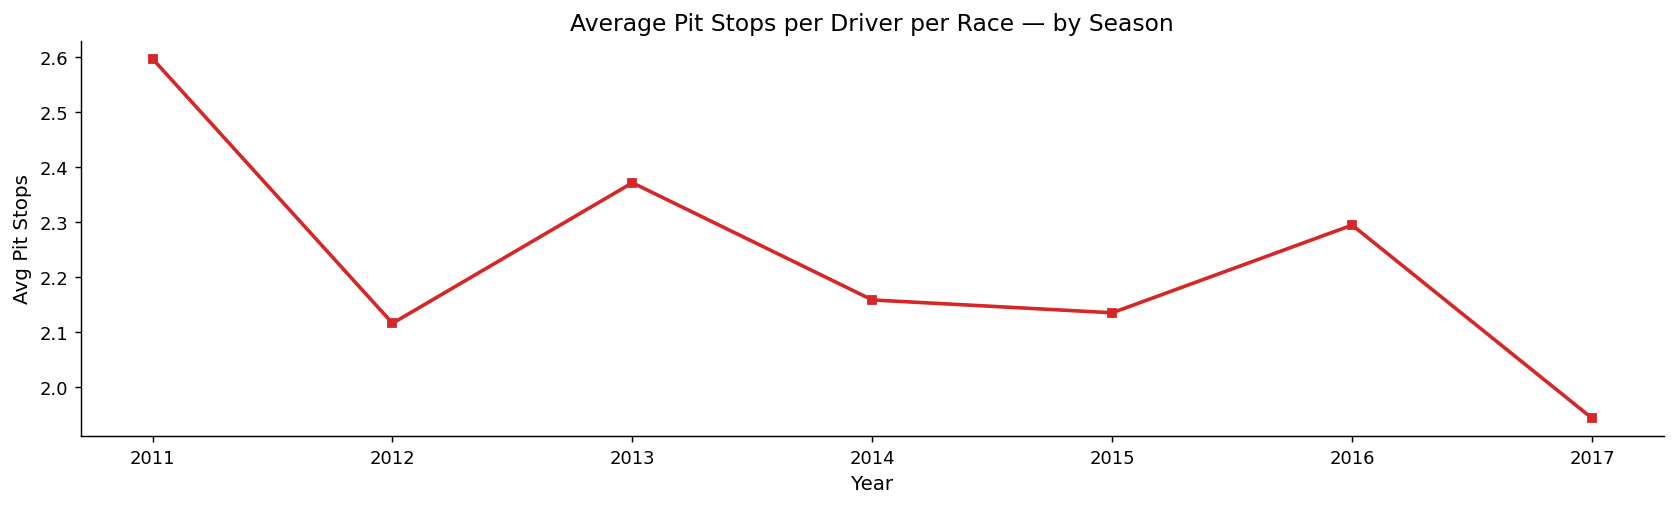

In [45]:
# ── Pit Stops + Races: Average pit stops per race by year ─────────────────────
if 'raceId' in pit_stops.columns and 'raceId' in races.columns:
    yr_col = [c for c in races.columns if 'year' in c.lower()]
    drv_col = [c for c in pit_stops.columns if 'driver' in c.lower() and 'id' in c.lower()]
    race_col_ps = [c for c in pit_stops.columns if 'race' in c.lower() and 'id' in c.lower()]
    if yr_col and drv_col and race_col_ps:
        ps_merged = pit_stops.merge(races[['raceId'] + yr_col], on='raceId', how='left')
        stops_per_driver_race = ps_merged.groupby(['raceId', drv_col[0], yr_col[0]]).size().reset_index(name='stops')
        avg_stops_yr = stops_per_driver_race.groupby(yr_col[0])['stops'].mean()

        fig, ax = plt.subplots(figsize=(13, 4))
        ax.plot(avg_stops_yr.index, avg_stops_yr.values, color=COLORS[3], linewidth=2, marker='s', markersize=4)
        ax.set_title('Average Pit Stops per Driver per Race — by Season')
        ax.set_xlabel('Year')
        ax.set_ylabel('Avg Pit Stops')
        plt.tight_layout()
        plt.savefig(FIG_DIR / '15_avg_pitstops_per_year.png', bbox_inches='tight')
        plt.show()

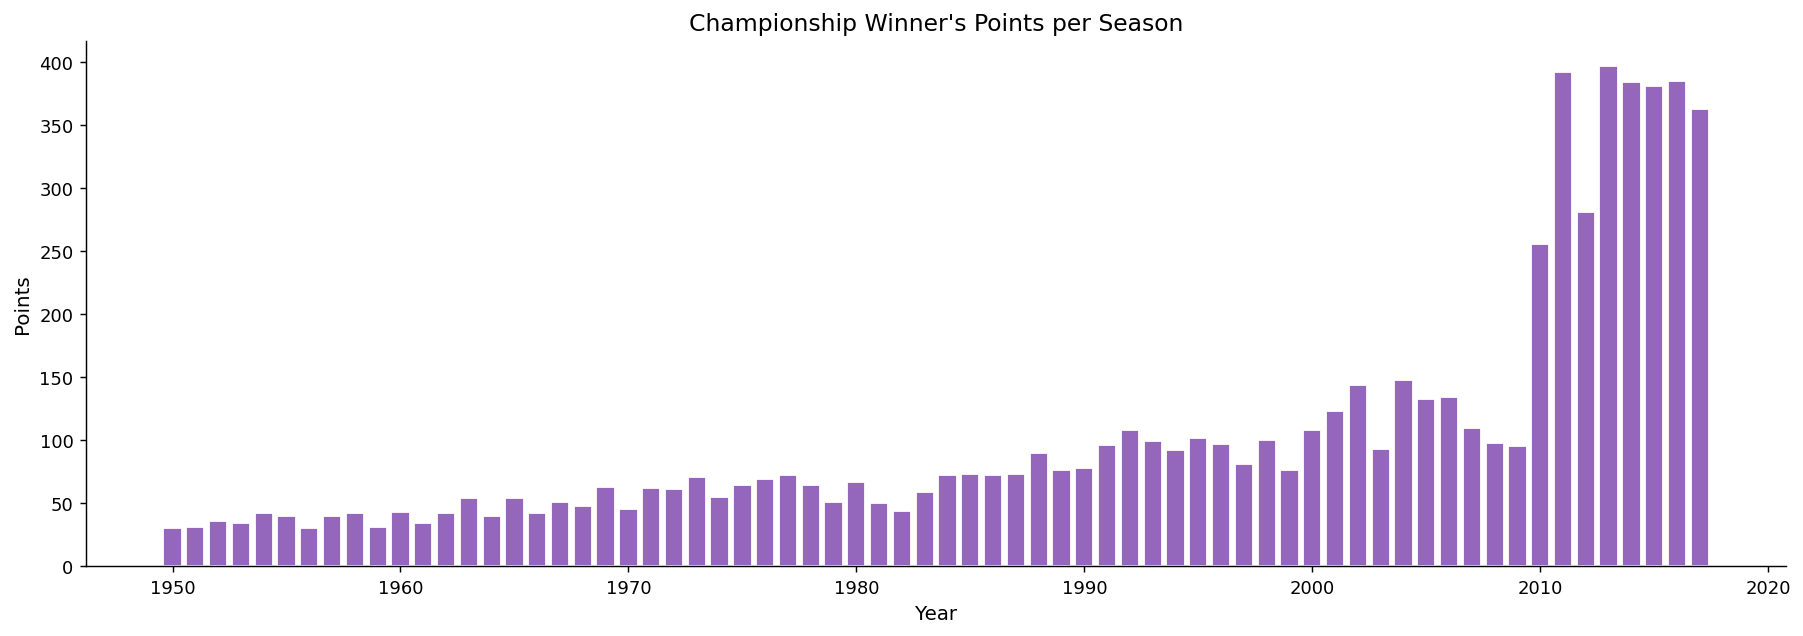

In [46]:
# ── Driver Standings + Races: Championship points leader per year ──────────────
if 'raceId' in drv_standings.columns and 'raceId' in races.columns:
    yr_col = [c for c in races.columns if 'year' in c.lower()]
    ds_pos2 = [c for c in drv_standings.columns if 'posit' in c.lower()]
    ds_pts2 = [c for c in drv_standings.columns if 'point' in c.lower()]
    ds_drv2 = [c for c in drv_standings.columns if 'driver' in c.lower() and 'id' in c.lower()]

    if yr_col and ds_pos2 and ds_pts2 and ds_drv2:
        ds_merged = drv_standings.merge(races[['raceId'] + yr_col], on='raceId', how='left')
        ds_merged['_pos'] = pd.to_numeric(ds_merged[ds_pos2[0]], errors='coerce')
        ds_merged['_pts'] = pd.to_numeric(ds_merged[ds_pts2[0]], errors='coerce')

        # Final standing per year = last race round
        last_race = ds_merged.groupby([yr_col[0], ds_drv2[0]])['_pts'].max().reset_index()
        champions = last_race.loc[last_race.groupby(yr_col[0])['_pts'].idxmax()]
        champions = champions.sort_values(yr_col[0])

        fig, ax = plt.subplots(figsize=(14, 5))
        ax.bar(champions[yr_col[0]], champions['_pts'], color=COLORS[4], edgecolor='white')
        ax.set_title('Championship Winner\'s Points per Season')
        ax.set_xlabel('Year')
        ax.set_ylabel('Points')
        plt.tight_layout()
        plt.savefig(FIG_DIR / '15_champion_points_per_year.png', bbox_inches='tight')
        plt.show()

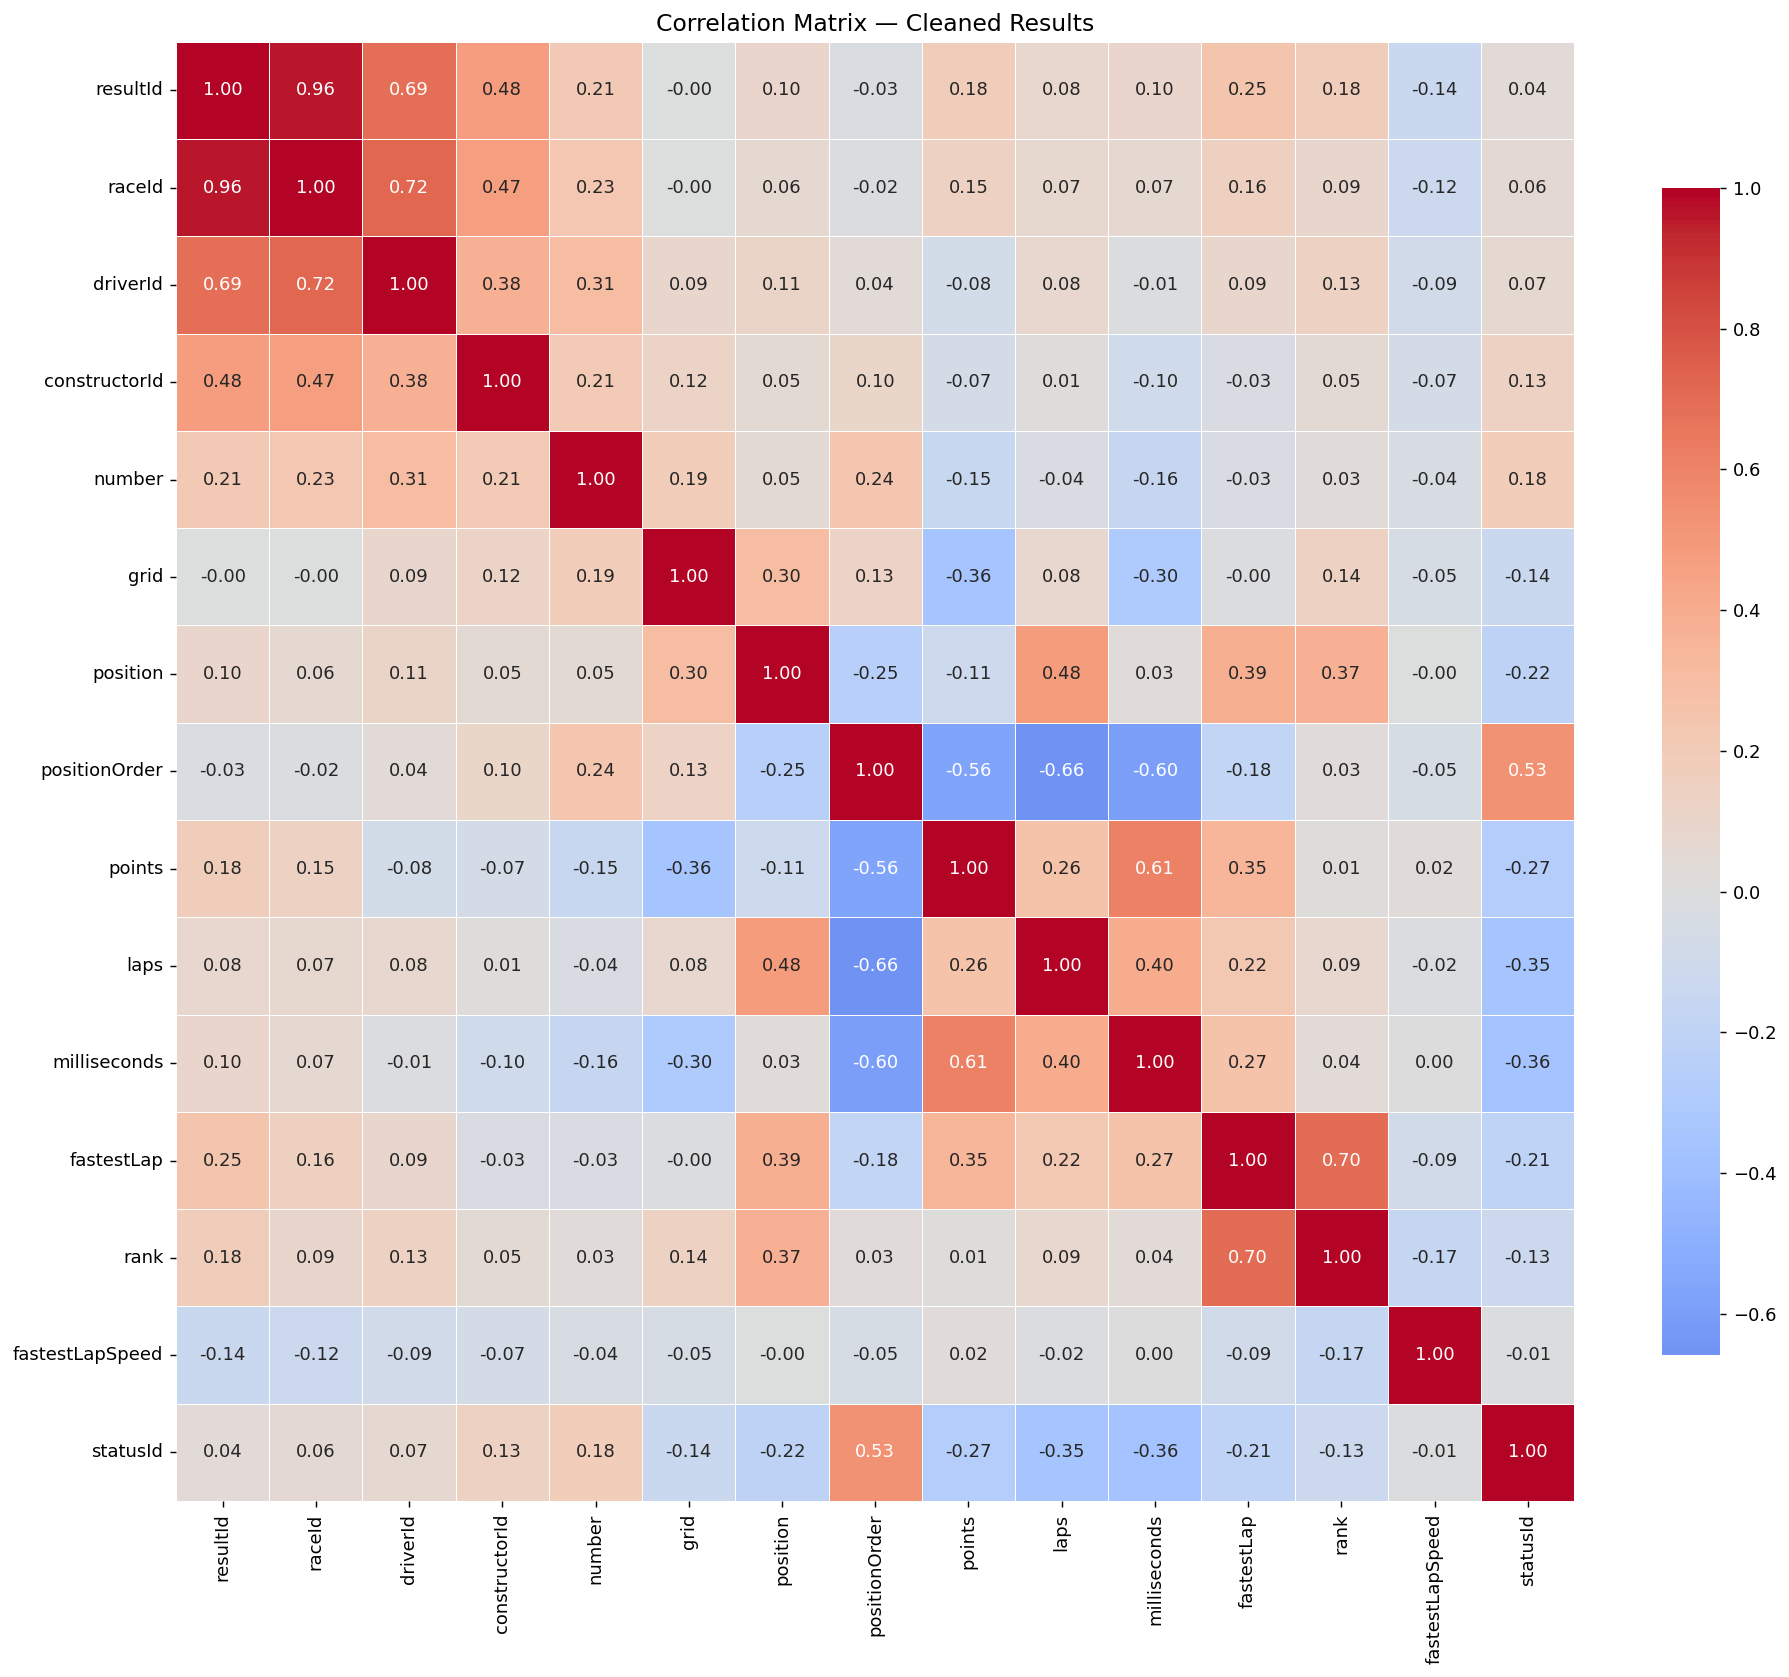

In [47]:
# ── Correlation heatmap of numeric columns in Results ─────────────────────────
num_results = results.select_dtypes(include='number')
if num_results.shape[1] > 1:
    corr_mat = num_results.corr()
    fig, ax = plt.subplots(figsize=(max(8, corr_mat.shape[0]), max(6, corr_mat.shape[0] - 2)))
    sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
    ax.set_title('Correlation Matrix — Cleaned Results')
    plt.tight_layout()
    plt.savefig(FIG_DIR / '15_results_correlation.png', bbox_inches='tight')
    plt.show()

---
## 16. EDA Summary & Key Findings

In [48]:
eda_findings = """
# F1 EDA Findings

## Dataset Coverage
- 13 cleaned CSV files covering circuits, drivers, constructors, races, seasons,
  results, qualifying, pit stops, lap times, standings (driver + constructor), and status.

## Key Observations

### Circuits
- Circuits are distributed globally; a small number of countries host multiple venues.
- Altitude varies significantly — some circuits are near sea level while others are at high elevation,
  which can affect engine performance.

### Drivers
- The driver pool is heavily skewed toward European nationalities.
- Birth year distribution reveals waves of driver generations entering the sport.

### Seasons & Races
- The calendar has grown substantially over the decades (from ~8 to 20+ races/season).
- A small number of Grand Prix names dominate the historical count.

### Results
- The majority of race entries score zero points, reflecting that points only go to the top finishers.
- Grid position has a strong positive correlation with finish position, but significant movement occurs.

### Qualifying
- Q2 and Q3 times are missing for earlier seasons (format introduced in 2005).
- Qualifying position is the strongest single predictor of race finish.

### Pit Stops
- Most pit stops are 2–4 seconds (modern era); longer stops suggest mechanical issues.
- Pit stop count per race peaked in the era of tyre changes and has since standardised.

### Lap Times
- Median lap times vary widely by circuit; overall times have trended downward with faster cars.
- A slight performance drop is visible across a stint (tyre degradation).

### Standings
- Championship leader appearances concentrate around a small group of elite drivers.
- Points totals for champions have grown as race calendars expanded.

## Hypotheses for Next Steps
- H1: Drivers with below-median qualifying gaps vs teammate have higher points-per-race.
- H2: Fewer pit stops correlate with better race finish in the hybrid era.
- H3: Mechanical DNF rate has declined each decade due to improved reliability.
- H4: Constructor budget (proxied by championship position) predicts the following season's points.
"""

REPORT_DIR.mkdir(exist_ok=True)
(REPORT_DIR / 'eda_findings.md').write_text(eda_findings)
print('EDA findings saved to reports/eda_findings.md')
print(eda_findings)

EDA findings saved to reports/eda_findings.md

# F1 EDA Findings

## Dataset Coverage
- 13 cleaned CSV files covering circuits, drivers, constructors, races, seasons,
  results, qualifying, pit stops, lap times, standings (driver + constructor), and status.

## Key Observations

### Circuits
- Circuits are distributed globally; a small number of countries host multiple venues.
- Altitude varies significantly — some circuits are near sea level while others are at high elevation,
  which can affect engine performance.

### Drivers
- The driver pool is heavily skewed toward European nationalities.
- Birth year distribution reveals waves of driver generations entering the sport.

### Seasons & Races
- The calendar has grown substantially over the decades (from ~8 to 20+ races/season).
- A small number of Grand Prix names dominate the historical count.

### Results
- The majority of race entries score zero points, reflecting that points only go to the top finishers.
- Grid position has a st